# EDA — Componente A (variante CHIRPS): Detección de Anomalías en Campañas Agrícolas

Análisis exploratorio de `data/processed/panel_nucleo.parquet` **con CHIRPS integrado**
(precipitación diaria v2.0, 0.05°, por centroide departamental, vía Google Earth Engine).

**Región núcleo pampeana** · 26 departamentos × soja y maíz · campañas 1981/82–2024/25

Este notebook es una **copia extendida** de `eda_componente_a_final.ipynb` (preservado como
registro). Re-ejecuta las secciones validadas con el panel nuevo y agrega las secciones que
aprovechan CHIRPS: feature engineering del período crítico (SPI, rachas secas, precip
quincenal), revisión de redundancia con NASA POWER, set de features definitivo del AE, y una
columna de confianza diagnóstica.

Hilo conductor:

1. **Contexto del panel** — estructura, faltantes y señal temporal del target
2. **Ground truth proxy** — etiquetado de campañas anómalas (`z_rinde < −1.5`)
3. **Espacio de features del AE** — correlación, dimensionalidad y separabilidad
4. **Proyecciones 2D** — separabilidad visual y distribution shift
5. **Variabilidad departamental** — justificación de la normalización por departamento
6. **Feature engineering CHIRPS** — SPI, rachas secas, precip quincenal del período crítico
7. **Redundancia CHIRPS ↔ NASA** — decisión de fuente única + PCA con el set definitivo
8. **Columna de confianza** — diagnóstico post-hoc (no entra a ningún modelo)
9. **Exportación de artefactos** — por cultivo (`_soja` / `_maiz`)

---

**Principios de diseño respetados en todo el notebook:**
- `rinde_kgha` y sus derivados (incl. `z_rinde`) **nunca** son features del AE — solo etiquetan.
- **Criterio de anomalía:** `es_anomala = z_rinde < −1.5` (media móvil de 5 años, sin leakage).
  El ONI quedó **descartado como criterio** y se conserva solo como *feature* de entrada.
- Toda estadística de normalización / estandarización (z-score, SPI) se calcula
  **exclusivamente sobre train**.
- Soja y maíz se analizan y se exportan **por separado**.

**Splits temporales:** `train` ≤ 2017 · `val` 2018–2020 · `test` 2021–2024 (incluye la sequía 2022/23).


## 0. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

# pyarrow debe inicializarse antes que numba/llvmlite (umap)
ROOT = Path.cwd()
if not (ROOT / "data").exists(): ROOT = ROOT.parent

panel_path = ROOT / "data" / "processed" / "panel_nucleo.parquet"

if not panel_path.exists():
    raise FileNotFoundError("El archivo 'panel_nucleo.parquet' no se encuentra en la ruta esperada. Ejecuta el script de procesamiento de datos para generar este archivo.")

_PANEL = pd.read_parquet(panel_path)

try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])
    import umap

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.patches import Ellipse
from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
RANDOM_STATE = 42

C:\Users\balta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = _PANEL.copy()

# Splits temporales 
def asignar_split(y):
    if y <= 2017: return "train"
    if y <= 2020: return "val"
    return "test"
df["split"] = df["campania_inicio"].apply(asignar_split)

# Familias de columnas 
TARGET     = "rinde_kgha"
ONI_COLS   = ["oni_oct", "oni_nov", "oni_dic", "oni_ene", "oni_feb"]
MAGYP_COLS = ["sup_sembrada_ha", "sup_cosechada_ha", "produccion_tn"]
NDVI_COLS  = [c for c in df.columns if c.startswith("ndvi")]
VAR_ORDER  = ["t2m", "t2m_max", "t2m_min", "prectotcorr", "rh2m", "allsky_sfc_sw_dwn", "ws2m"]
MESES      = ["sep", "oct", "nov", "dic", "ene", "feb", "mar"]
NASA_COLS  = [f"{v}_{m}" for v in VAR_ORDER for m in MESES if f"{v}_{m}" in df.columns]

def nasa_var_cols(var):
    """Columnas mensuales de una variable NASA, ordenadas sep→mar."""
    return [c for c in NASA_COLS if c.rsplit("_", 1)[0] == var]

# Paletas 
CROP_COLORS = {"soja": "#2ca02c", "maiz": "#ff7f0e"}
ENSO_COLORS = {"Nina": "#1f77b4", "Neutro": "grey", "Nino": "#d62728"}
ANOM_COLORS = {"normal": "#2ca02c", "anomala": "#d62728"}
PROV_COLORS = {"SANTA FE": "#1f77b4", "CORDOBA": "#ff7f0e", "BUENOS AIRES": "#2ca02c"}
SEQUIAS     = {1988: "1988/89", 2008: "2008/09", 2017: "2017/18", 2022: "2022/23"}

print("Panel:", df.shape, "| NASA_COLS:", len(NASA_COLS), "| NDVI:", len(NDVI_COLS))
print(df.groupby("split")["campania_inicio"].agg(["min", "max", "count"]))

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumeric columns: {len(numeric_columns)}, Categorical columns: {len(categorical_columns)}")
print(f"Categorical columns: {categorical_columns}")

df.head()

Panel: (2287, 77) | NASA_COLS: 49 | NDVI: 4
        min   max  count
split                   
test   2021  2024    208
train  1981  2017   1923
val    2018  2020    156

Numeric columns: 72, Categorical columns: 5
Categorical columns: ['cultivo', 'provincia', 'departamento', 'campania', 'split']


,cultivo,campania_inicio,provincia,departamento,sup_sembrada_ha,sup_cosechada_ha,produccion_tn,rinde_kgha,lat_centroide,lon_centroide,campania,oni_dic,oni_ene,oni_feb,oni_nov,oni_oct,allsky_sfc_sw_dwn_dic,allsky_sfc_sw_dwn_ene,allsky_sfc_sw_dwn_feb,allsky_sfc_sw_dwn_mar,allsky_sfc_sw_dwn_nov,allsky_sfc_sw_dwn_oct,allsky_sfc_sw_dwn_sep,prectotcorr_dic,prectotcorr_ene,prectotcorr_feb,prectotcorr_mar,prectotcorr_nov,prectotcorr_oct,prectotcorr_sep,...,t2m_max_mar,t2m_max_nov,t2m_max_oct,t2m_max_sep,t2m_min_dic,t2m_min_ene,t2m_min_feb,t2m_min_mar,t2m_min_nov,t2m_min_oct,t2m_min_sep,ws2m_dic,ws2m_ene,ws2m_feb,ws2m_mar,ws2m_nov,ws2m_oct,ws2m_sep,ndvi_mean,ndvi_min,ndvi_max,ndvi_anomalia_pct,chirps_precip_sep,chirps_precip_oct,chirps_precip_nov,chirps_precip_dic,chirps_precip_ene,chirps_precip_feb,chirps_precip_mar,split
0,soja,1981,BUENOS AIRES,Arrecifes,29000,29000.0,64000.0,2207.0,-34.07,-60.10,1981/82,-0.08,-0.05,0.07,-0.15,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.595806,6.057419,3.620357,3.433226,3.298333,2.325161,1.395000,...,29.363226,27.812333,24.960000,20.556333,15.753871,16.680323,15.472143,15.656129,13.510000,10.216452,6.740333,2.377419,2.391290,2.435357,2.148065,2.778333,2.617097,2.893000,NaN,NaN,NaN,NaN,1.520152,2.306435,5.323527,2.746997,3.970391,5.641752,3.083327,train
1,soja,1981,BUENOS AIRES,Baradero,18500,18500.0,37000.0,2000.0,-33.81,-59.51,1981/82,-0.08,-0.05,0.07,-0.15,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.731935,4.506452,3.667143,3.003548,2.684000,1.715484,1.455000,...,29.650000,27.740000,24.486129,19.865667,15.823871,16.844194,15.871786,15.955484,13.746000,10.372903,6.914333,2.228387,2.305161,2.334643,2.086452,2.612333,2.376129,2.705333,NaN,NaN,NaN,NaN,1.664068,2.433791,4.723830,2.754326,3.838558,6.047568,0.962571,train
2,soja,1981,BUENOS AIRES,Capitan Sarmiento,8000,8000.0,14000.0,1750.0,-34.18,-59.79,1981/82,-0.08,-0.05,0.07,-0.15,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.595806,6.057419,3.620357,3.433226,3.298333,2.325161,1.395000,...,29.363226,27.812333,24.960000,20.556333,15.753871,16.680323,15.472143,15.656129,13.510000,10.216452,6.740333,2.377419,2.391290,2.435357,2.148065,2.778333,2.617097,2.893000,NaN,NaN,NaN,NaN,1.777693,2.508090,6.437624,2.304079,4.588508,5.413438,2.628128,train
3,soja,1981,BUENOS AIRES,Carmen De Areco,5000,5000.0,10500.0,2100.0,-34.38,-59.82,1981/82,-0.08,-0.05,0.07,-0.15,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.337097,4.668387,4.040000,4.078710,3.146000,2.111290,1.298000,...,29.017742,26.938667,24.290645,19.932333,15.335806,16.361935,14.946071,15.240645,12.982667,9.687742,6.397333,2.616452,2.607097,2.618214,2.309677,2.913333,2.696129,2.924333,NaN,NaN,NaN,NaN,1.863475,2.997575,6.529800,2.588738,3.279764,4.831472,2.562533,train
4,soja,1981,BUENOS AIRES,Chacabuco,23000,23000.0,49000.0,2130.0,-34.64,-60.47,1981/82,-0.08,-0.05,0.07,-0.15,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.201290,5.562581,4.152500,4.200968,3.792333,2.569032,1.201333,...,28.319032,26.376667,23.845161,20.159333,15.369032,16.477742,14.899643,15.245806,12.923667,9.780645,6.635333,2.571290,2.550968,2.562143,2.293226,2.810000,2.680645,2.876667,NaN,NaN,NaN,NaN,0.792996,3.267241,6.084749,2.609514,3.734464,4.365347,3.258561,train


In [3]:
df.describe()

,campania_inicio,sup_sembrada_ha,sup_cosechada_ha,produccion_tn,rinde_kgha,lat_centroide,lon_centroide,oni_dic,oni_ene,oni_feb,oni_nov,oni_oct,allsky_sfc_sw_dwn_dic,allsky_sfc_sw_dwn_ene,allsky_sfc_sw_dwn_feb,allsky_sfc_sw_dwn_mar,allsky_sfc_sw_dwn_nov,allsky_sfc_sw_dwn_oct,allsky_sfc_sw_dwn_sep,prectotcorr_dic,prectotcorr_ene,prectotcorr_feb,prectotcorr_mar,prectotcorr_nov,prectotcorr_oct,prectotcorr_sep,rh2m_dic,rh2m_ene,rh2m_feb,rh2m_mar,...,t2m_max_feb,t2m_max_mar,t2m_max_nov,t2m_max_oct,t2m_max_sep,t2m_min_dic,t2m_min_ene,t2m_min_feb,t2m_min_mar,t2m_min_nov,t2m_min_oct,t2m_min_sep,ws2m_dic,ws2m_ene,ws2m_feb,ws2m_mar,ws2m_nov,ws2m_oct,ws2m_sep,ndvi_mean,ndvi_min,ndvi_max,ndvi_anomalia_pct,chirps_precip_sep,chirps_precip_oct,chirps_precip_nov,chirps_precip_dic,chirps_precip_ene,chirps_precip_feb,chirps_precip_mar
count,2287.000000,2287.000000,2287.000000,2.287000e+03,2287.000000,2287.000000,2287.000000,2287.000000,2287.00000,2287.000000,2287.000000,2287.000000,2131.000000,2183.000000,2183.000000,2183.000000,2131.000000,2131.000000,2131.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,...,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,1196.000000,1196.000000,1196.000000,1196.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000,2287.000000
mean,2002.507215,89913.458679,86971.913424,3.233237e+05,4740.223000,-33.669777,-60.967822,0.030162,0.03948,0.049047,0.026559,0.029602,26.270451,25.920817,22.774978,18.758379,24.581073,20.468694,16.897185,3.905673,3.924562,4.285704,4.235375,3.799754,3.710795,1.898830,59.914772,59.869350,65.392023,70.233351,...,30.456257,27.994468,28.265488,24.958560,21.368880,16.282418,18.067323,17.099518,15.192174,13.686688,10.807196,7.602414,2.171698,2.007257,1.927874,1.923353,2.358779,2.390758,2.374830,0.584190,0.473713,0.690062,99.369728,1.808874,3.594520,3.442315,3.479267,3.825139,4.057774,4.084865
std,12.699289,117584.830091,115356.641797,4.164963e+05,2628.377492,0.612026,1.021927,1.161092,1.09431,0.940568,1.127091,1.016791,1.707973,1.350591,1.874419,1.426263,1.443367,1.665063,1.296081,2.295480,1.655998,2.641307,2.499160,1.598776,1.871354,1.418838,7.998545,7.606344,7.487812,7.414063,...,1.765313,2.054399,1.968446,1.710703,1.496880,1.401900,1.221761,1.259858,1.626234,1.290877,1.178511,1.213152,0.855068,0.815930,0.790874,0.799874,0.898504,0.882312,0.850682,0.086283,0.105698,0.109301,6.076256,1.044423,1.601821,1.377958,1.794178,1.497404,2.335593,2.216240
min,1981.000000,1500.000000,1500.000000,2.500000e+03,697.000000,-34.640000,-63.420000,-1.850000,-1.69000,-1.520000,-1.800000,-1.640000,21.621935,21.866129,17.341429,14.237742,20.160000,15.668065,13.454667,0.165161,0.892581,0.271786,0.365484,0.304333,0.370000,0.000667,38.494194,42.788065,42.285357,45.162258,...,25.547857,23.658065,23.574667,19.534194,18.022333,12.816774,14.712581,14.030357,11.328387,9.834667,8.161935,4.983667,0.148710,0.046129,0.018276,0.017742,0.229333,0.294839,0.368000,0.300878,0.241962,0.352000,67.468420,0.042733,0.936399,0.855092,0.391384,0.852100,0.624651,0.277738
25%,1992.000000,19000.000000,17652.000000,8.140000e+04,2625.000000,-34.200000,-61.470000,-0.865000,-0.79500,-0.730000,-0.880000,-0.700000,25.199032,25.111290,21.524871,17.863226,23.599000,19.261290,15.906667,2.107742,2.668387,2.287931,2.617419,2.620833,2.365806,0.827500,53.315484,54.669677,60.917069,65.299839,...,29.417321,26.426935,26.884333,23.791290,20.304833,15.233548,17.208871,16.107321,14.065161,12.886500,9.964839,6.668167,1.794677,1.589194,1.545536,1.523387,1.963000,2.027419,1.939833,0.549810,0.381682,0.654859,96.564496,1.002700,2.507750,2.412947,2.072506,2.689654,2.341976,2.691491
50%,2003.000000,44000.000000,42500.000000,1.740000e+05,3763.000000,-33.680000,-60.730000,-0.1500

---
## 1. Contexto del panel

Antes de construir el etiquetado de anomalías, verificamos la estructura del panel y el comportamiento del target para entender qué tipo de variabilidad existe y cuánto de ella se debe al clima (señal del AE) versus a la mejora tecnológica (tendencia secular que hay que separar).

### 1.1 Estructura y cobertura

Filas: 2287 | Duplicados en clave (cultivo, depto, campaña): 0
Campañas: 1981–2024 (44 años) | Departamentos: 26 | Cultivos: ['soja', 'maiz']

Faltantes promedio por fuente:
  MAGyP :   0.0%
  ONI   :   0.0%
  NASA  :   0.8%
  NDVI  :  47.7%
  Target 'rinde_kgha': 0 NaN


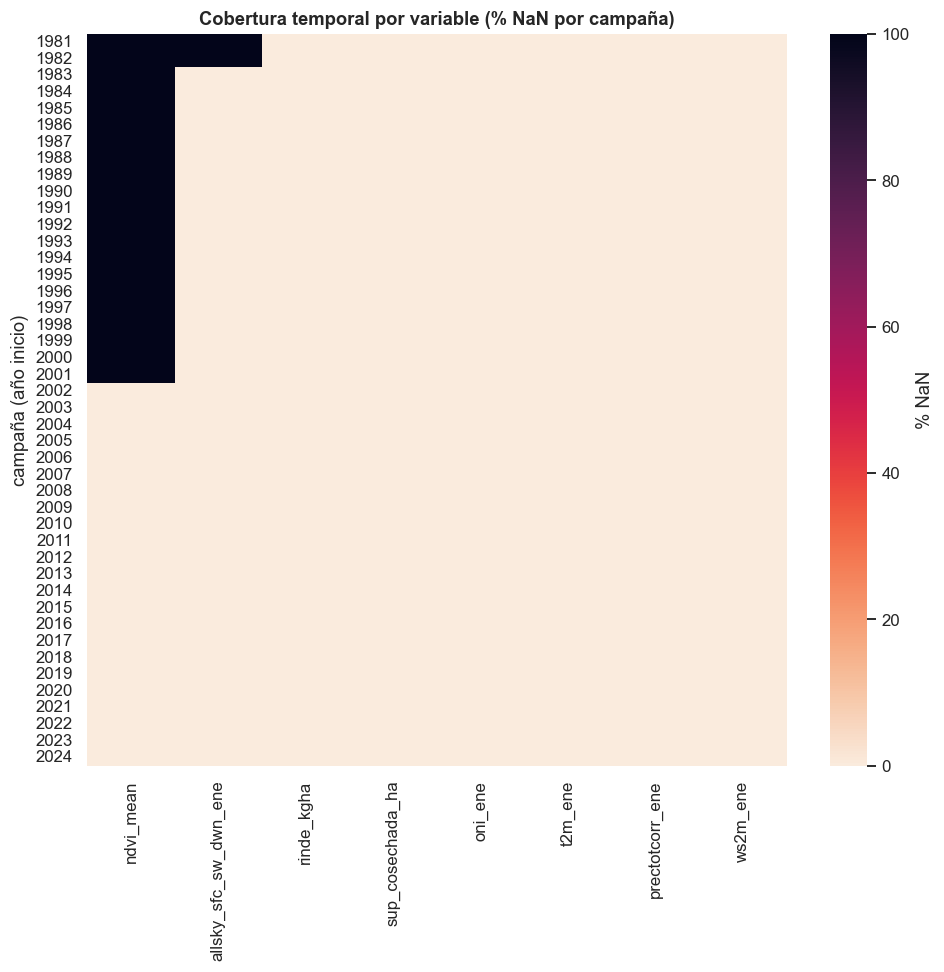

In [4]:
print(f"Filas: {len(df)} | Duplicados en clave (cultivo, depto, campaña): "
      f"{df.duplicated(['cultivo', 'departamento', 'campania_inicio']).sum()}")
print(f"Campañas: {df['campania_inicio'].min()}–{df['campania_inicio'].max()} "
      f"({df['campania_inicio'].nunique()} años) | Departamentos: {df['departamento'].nunique()} "
      f"| Cultivos: {df['cultivo'].unique().tolist()}")

print("\nFaltantes promedio por fuente:")
for name, cols in [("MAGyP", MAGYP_COLS), ("ONI", ONI_COLS), ("NASA", NASA_COLS), ("NDVI", NDVI_COLS)]:
    print(f"  {name:6s}: {df[cols].isna().mean().mean()*100:5.1f}%")
print(f"  Target '{TARGET}': {df[TARGET].isna().sum()} NaN")

# Cobertura temporal de faltantes por variable representativa
rep_cols = ["ndvi_mean", "allsky_sfc_sw_dwn_ene", "rinde_kgha", "sup_cosechada_ha", "oni_ene",
            "t2m_ene", "prectotcorr_ene", "ws2m_ene"]
na_by_camp = df.groupby("campania_inicio")[rep_cols].apply(lambda g: g.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(na_by_camp, cmap="rocket_r", vmin=0, vmax=100,
            cbar_kws={"label": "% NaN"}, ax=ax)
ax.set_title("Cobertura temporal por variable (% NaN por campaña)")
ax.set_ylabel("campaña (año inicio)")
plt.tight_layout(); plt.show()

> **NDVI:** ~47.7% NaN estructurales — MODIS opera recién desde 2002. Se trata como ablation sobre el subset 2002+, no como faltante a imputar.

### 1.2 Variable objetivo: `rinde_kgha`

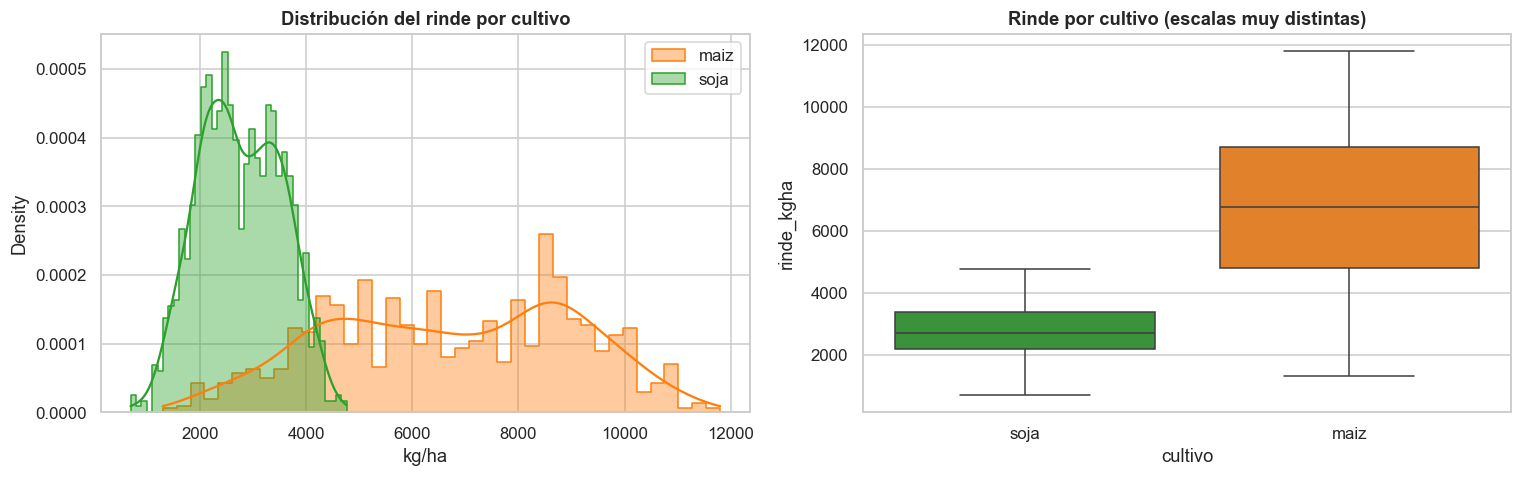

,count,mean,median,std,skew,min,max
cultivo,,,,,,,
maiz,1144,6718.2,6764.0,2319.6,-0.1,1300.0,11800.0
soja,1143,2760.5,2700.0,775.6,0.0,697.0,4764.0


In [5]:
# Distribución del rinde por cultivo
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for cult, g in df.groupby("cultivo"):
    sns.histplot(g[TARGET], bins=40, kde=True, ax=axes[0], label=cult,
                 color=CROP_COLORS[cult], element="step", stat="density", alpha=0.4)
axes[0].set_title("Distribución del rinde por cultivo")
axes[0].set_xlabel("kg/ha"); axes[0].legend()
sns.boxplot(data=df, x="cultivo", y=TARGET, hue="cultivo",
            palette=CROP_COLORS, ax=axes[1], legend=False)
axes[1].set_title("Rinde por cultivo (escalas muy distintas)")
plt.tight_layout(); plt.show()

display(df.groupby("cultivo")[TARGET].agg(["count", "mean", "median", "std", "skew", "min", "max"]).round(1))

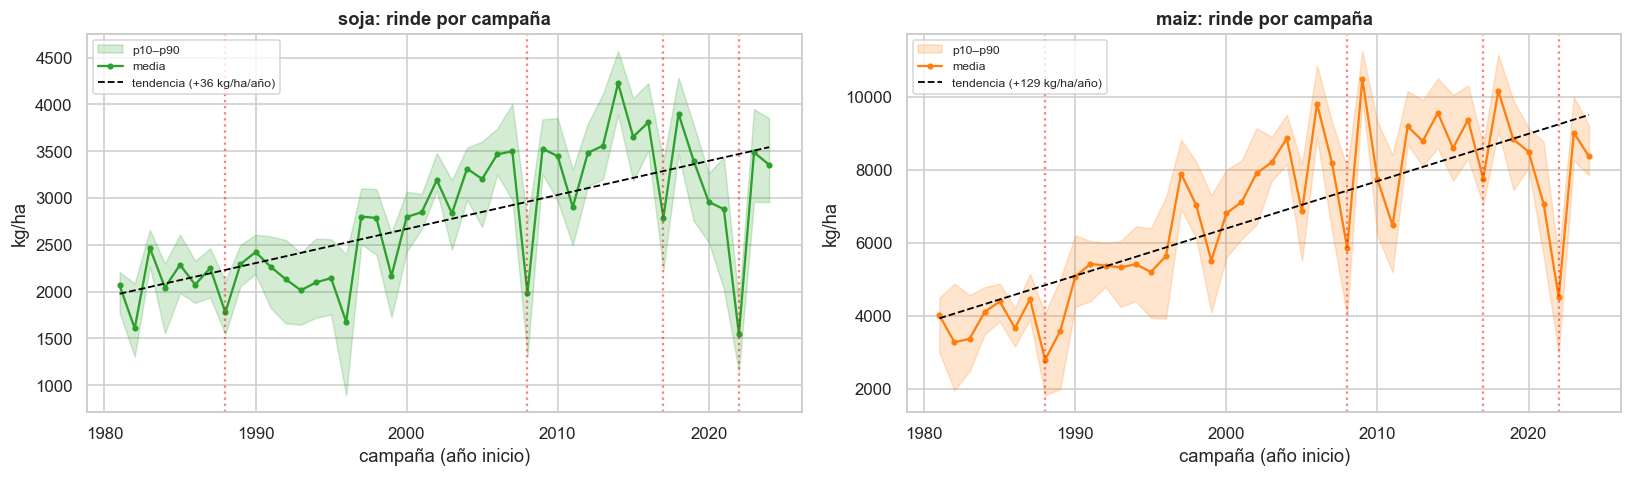

Líneas punteadas rojas = sequías conocidas. Tendencia ascendente = mejora tecnológica (no clima).


In [6]:
# Distribución y evolución temporal del rinde
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharex=False)

# Evolución temporal
for ax, cult in zip(axes, ["soja", "maiz"]):
    g = df[df["cultivo"] == cult].groupby("campania_inicio")[TARGET]
    m, lo, hi = g.mean(), g.quantile(.1), g.quantile(.9)
    ax.fill_between(m.index, lo, hi, alpha=.2, color=CROP_COLORS[cult], label="p10–p90")
    ax.plot(m.index, m.values, marker="o", ms=3, color=CROP_COLORS[cult], label="media")
    z = np.polyfit(m.index, m.values, 1)
    ax.plot(m.index, np.poly1d(z)(m.index), "--", color="black", lw=1.2,
            label=f"tendencia (+{z[0]:.0f} kg/ha/año)")
    for y in SEQUIAS:
        ax.axvline(y, color="red", ls=":", alpha=.5)
    ax.set_title(f"{cult}: rinde por campaña")
    ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("kg/ha"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Líneas punteadas rojas = sequías conocidas. Tendencia ascendente = mejora tecnológica (no clima).")

### Anomalías de rinde (detrend)

Para separar la **variabilidad climática** de la **mejora tecnológica**, calculamos el residuo porcentual del rinde respecto de su tendencia lineal por cultivo. Las campañas con residuo muy negativo son las anómalas — el insumo para el componente de detección de anomalías del proyecto.

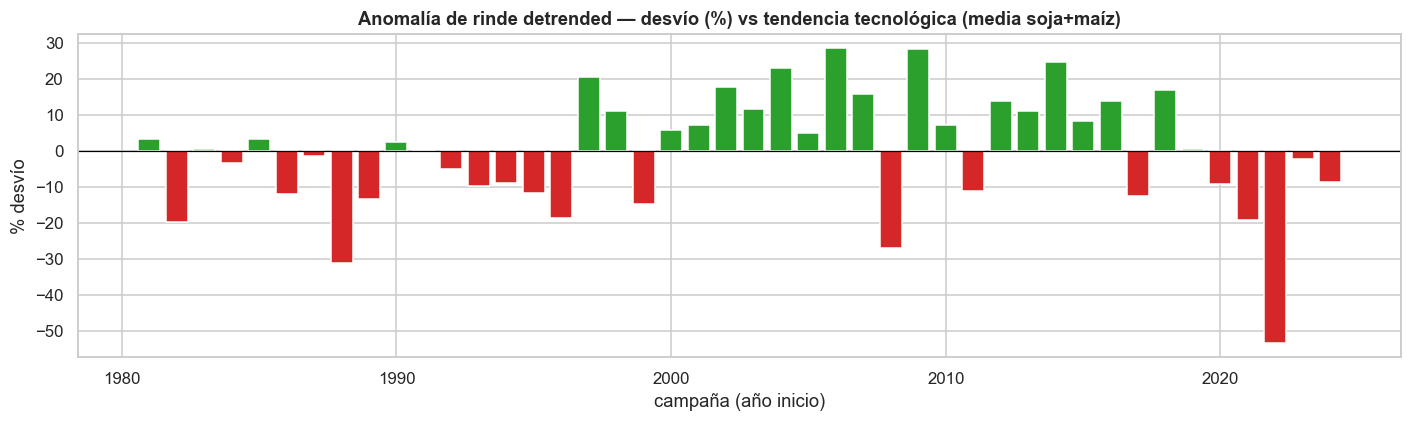

Peores campañas (desvío % vs tendencia):


campania_inicio
2022   -53.3
1988   -31.2
2008   -27.2
1982   -19.7
2021   -19.2
1996   -18.8
Name: _rinde_resid_pct, dtype: float64

In [7]:
# Anomalía de rinde = residuo vs tendencia lineal (separa clima de tecnología)
def detrend_residual(g):
    z = np.polyfit(g["campania_inicio"], g[TARGET], 1)
    pred = np.poly1d(z)(g["campania_inicio"])
    return (g[TARGET] - pred) / pred * 100

df["_rinde_resid_pct"] = df.groupby("cultivo", group_keys=False).apply(detrend_residual)

anom = df.groupby("campania_inicio")["_rinde_resid_pct"].mean().sort_index()
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(anom.index, anom.values,
       color=["#d62728" if v < 0 else "#2ca02c" for v in anom.values])
ax.axhline(0, color="black", lw=.8)
ax.set_title("Anomalía de rinde detrended — desvío (%) vs tendencia tecnológica (media soja+maíz)")
ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("% desvío")
plt.tight_layout(); plt.show()

print("Peores campañas (desvío % vs tendencia):"); display(anom.sort_values().head(6).round(1))

### 1.3 ONI / ENSO — driver climático global

El ONI es el principal predictor estacional conocido *antes* de la campaña. Se resume en un promedio Oct–Feb y se clasifica en fases La Niña / Neutro / El Niño.

> El efecto ENSO se mide sobre el **residuo detrended** para no confundir la señal climática con la mejora tecnológica.

ONI / ENSO (El Niño – La Niña)

El ONI es una serie **global** (igual para todos los deptos/cultivos de una campaña). Resumimos los 5 meses en un `_oni_mean` (Oct–Feb) y clasificamos cada campaña en La Niña (≤ −0.5), Neutro o El Niño (≥ +0.5). Es el principal driver climático *conocido de antemano*, así que su relación con el rinde es central para el pronóstico estacional.

> Para aislar el efecto climático de la tendencia tecnológica, el ENSO se compara contra el **residuo de rinde** (`_rinde_resid_pct`) calculado en la sección 3.

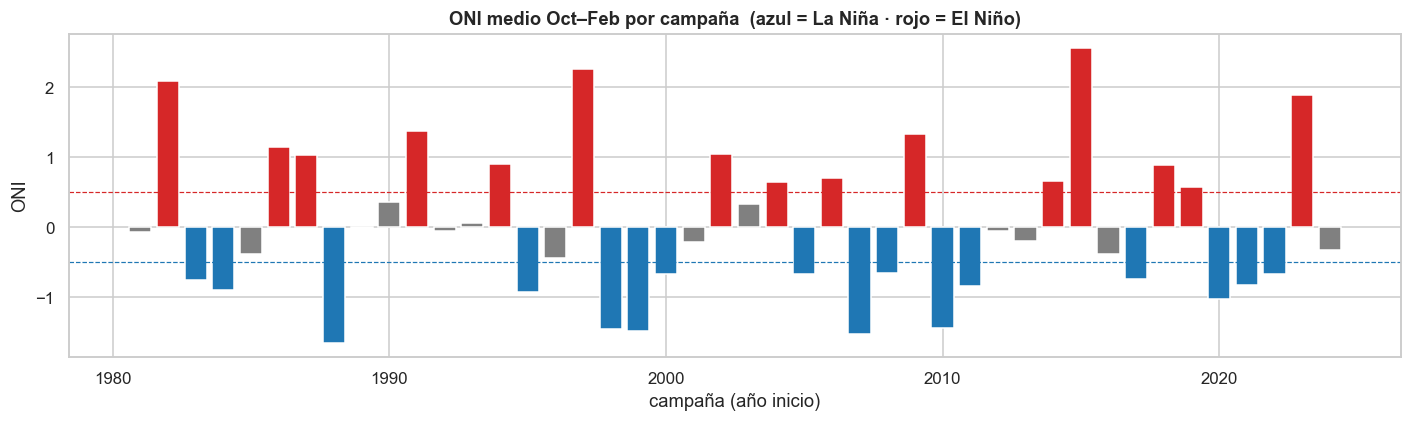

Campañas por fase ENSO: {'Nina': 16, 'Nino': 15, 'Neutro': 13}


In [8]:
# ONI medio Oct-Feb + clasificación ENSO
df["_oni_mean"] = df[ONI_COLS].mean(axis=1)
df["_enso"]     = pd.cut(df["_oni_mean"], [-np.inf, -0.5, 0.5, np.inf],
                         labels=["Nina", "Neutro", "Nino"]).astype(str)

oni_camp = df.groupby("campania_inicio")["_oni_mean"].first()
colors   = [ENSO_COLORS["Nina"] if v <= -0.5 else ENSO_COLORS["Nino"] if v >= 0.5
            else ENSO_COLORS["Neutro"] for v in oni_camp.values]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(oni_camp.index, oni_camp.values, color=colors)
ax.axhline(0.5, color="#d62728", ls="--", lw=.8)
ax.axhline(-0.5, color="#1f77b4", ls="--", lw=.8)
ax.set_title("ONI medio Oct–Feb por campaña  (azul = La Niña · rojo = El Niño)")
ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("ONI")
plt.tight_layout(); plt.show()
print("Campañas por fase ENSO:", df.groupby("campania_inicio")["_enso"].first().value_counts().to_dict())

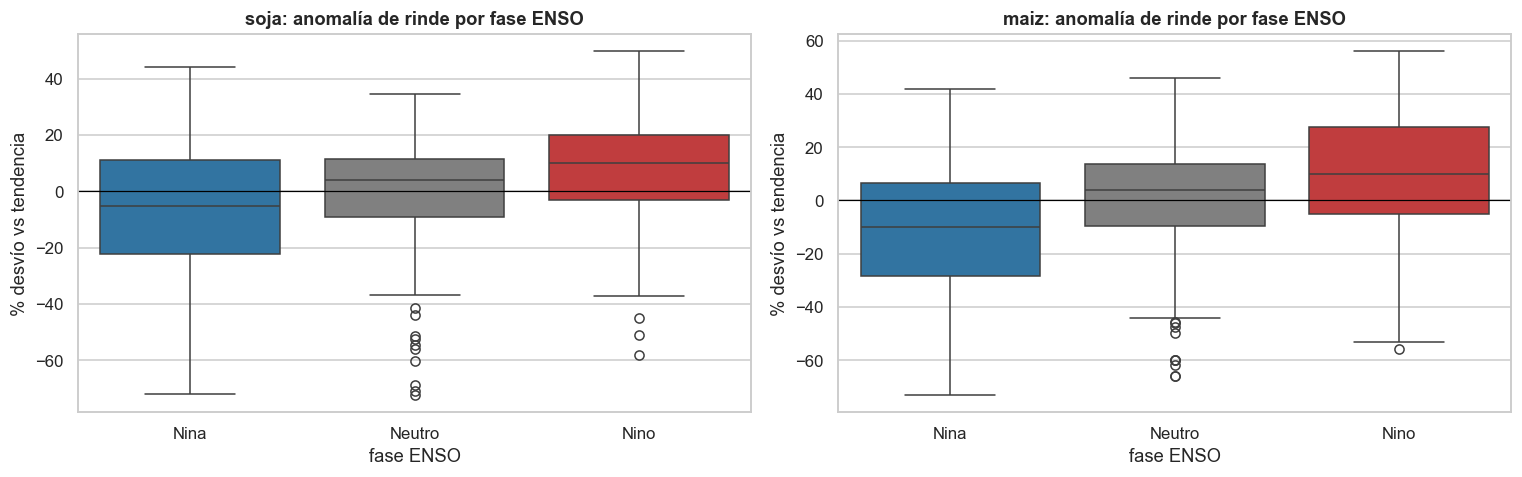

Anomalía media de rinde (%) por fase ENSO:


_enso,Neutro,Nina,Nino
cultivo,,,
maiz,1.5,-11.5,9.4
soja,0.2,-7.1,7.1


In [9]:
# Efecto ENSO sobre el rinde detrended
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, cult in zip(axes, ["soja", "maiz"]):
    g = df[df["cultivo"] == cult]
    sns.boxplot(data=g, x="_enso", y="_rinde_resid_pct", order=["Nina", "Neutro", "Nino"],
                hue="_enso", palette=ENSO_COLORS, legend=False, ax=ax)
    ax.axhline(0, color="black", lw=.8)
    ax.set_title(f"{cult}: anomalía de rinde por fase ENSO")
    ax.set_xlabel("fase ENSO"); ax.set_ylabel("% desvío vs tendencia")
plt.tight_layout(); plt.show()

print("Anomalía media de rinde (%) por fase ENSO:")
display(df.groupby(["cultivo", "_enso"])["_rinde_resid_pct"].mean().round(1).unstack())

### 1.4 Proxy de pérdida de cosecha: % superficie cosechada/sembrada

El cociente cosechada/sembrada captura el abandono de lotes — una señal de campaña anómala complementaria al rinde, independiente de la tendencia tecnológica.

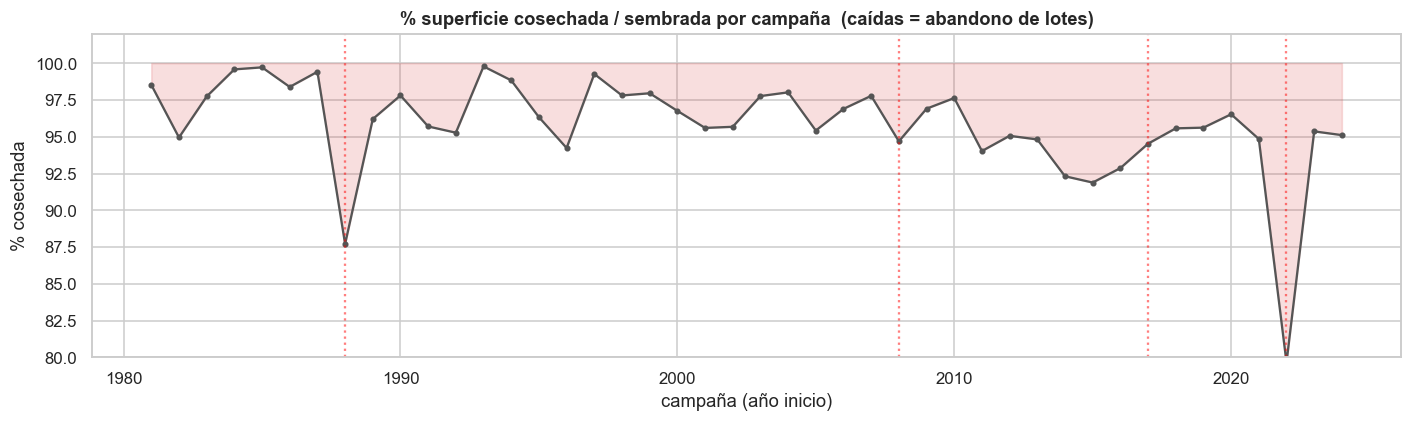

Campañas con más abandono (menor % cosechada):


campania_inicio
2022    79.6
1988    87.7
2015    91.9
2014    92.3
2016    92.9
Name: _pct_cosechada, dtype: float64

In [10]:
df["_pct_cosechada"] = df["sup_cosechada_ha"] / df["sup_sembrada_ha"] * 100
loss = df.groupby("campania_inicio")["_pct_cosechada"].mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(loss.index, loss.values, marker="o", ms=3, color="#555")
ax.fill_between(loss.index, loss.values, 100, alpha=.15, color="#d62728")
for y in SEQUIAS:
    ax.axvline(y, color="red", ls=":", alpha=.5)
ax.set_title("% superficie cosechada / sembrada por campaña  (caídas = abandono de lotes)")
ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("% cosechada")
ax.set_ylim(80, 102)
plt.tight_layout(); plt.show()

print("Campañas con más abandono (menor % cosechada):"); display(loss.sort_values().head(5).round(1))

---
## 2. Ground truth proxy — etiquetado formal de campañas anómalas

El AE es no supervisado y no usa etiquetas en el entrenamiento. Igual necesitamos un
etiquetado-proxy para (1) **excluir campañas anómalas del train** y (2) **medir la
performance del detector** contra un ground truth.

**Criterio de etiquetado (validado):** una fila (campaña × departamento × cultivo) es anómala si

| Criterio | Definición |
|---|---|
| `z_rinde < −1.5` | Rinde más de 1.5 desvíos por debajo de su media móvil de 5 años (ventana hacia atrás, `shift(1)` → sin leakage). |

> **ONI descartado como criterio.** El ONI es global (mismo valor para todos los deptos de
> una campaña) y etiquetaba como anómalos años Niña donde el rinde no cayó, contaminando la
> especificidad del ground truth. Se conserva únicamente como **feature de entrada**
> (`oni_mean_octfeb`), no como disparador de la etiqueta.


In [11]:
# ── ONI medio Oct-Feb (se conserva SOLO como feature, no como criterio) ──────
df["oni_mean_octfeb"] = df[ONI_COLS].mean(axis=1)

# ── Z-rinde: ventana móvil de 5 años hacia atrás, por departamento × cultivo ──
# shift(1): el año actual NO entra en su propia línea base (sin leakage)
# min_periods=3: necesita al menos 3 campañas previas; las primeras quedan NaN
df = df.sort_values(["departamento", "cultivo", "campania_inicio"]).reset_index(drop=True)
prev = df.groupby(["departamento", "cultivo"], sort=False)[TARGET].shift(1)
roll = prev.groupby([df["departamento"], df["cultivo"]], sort=False).rolling(5, min_periods=3)
df["rinde_roll_mean"] = roll.mean().reset_index(level=[0, 1], drop=True)
df["rinde_roll_std"]  = roll.std().reset_index(level=[0, 1], drop=True)
df["z_rinde"]         = (df[TARGET] - df["rinde_roll_mean"]) / df["rinde_roll_std"]

# ── Etiqueta booleana: criterio ÚNICO z_rinde < -1.5 (NaN -> normal) ──────────
df["es_anomala"]     = (df["z_rinde"] < -1.5).fillna(False)
df["label_anomalia"] = np.where(df["es_anomala"], "anomala", "normal")

n_anom = int(df["es_anomala"].sum())
print(f"Filas anómalas: {n_anom} ({df['es_anomala'].mean()*100:.1f}%) | criterio: z_rinde < -1.5")
print(f"Filas con z_rinde definido: {df['z_rinde'].notna().sum()} / {len(df)} "
      f"(las primeras 3 campañas por depto×cultivo quedan sin base → normal)")
# Comparación informativa: cuántas habría agregado el viejo criterio ONI (ya NO se usa)
solo_oni = ((df["oni_mean_octfeb"] <= -0.5) & ~df["es_anomala"]).sum()
print(f"[informativo] El viejo criterio ONI<=-0.5 habría sumado {solo_oni} filas anómalas "
      f"sin caída de rinde -> por eso se descartó.")


Filas anómalas: 290 (12.7%) | criterio: z_rinde < -1.5
Filas con z_rinde definido: 2131 / 2287 (las primeras 3 campañas por depto×cultivo quedan sin base → normal)
[informativo] El viejo criterio ONI<=-0.5 habría sumado 595 filas anómalas sin caída de rinde -> por eso se descartó.


### 2.1 Distribución espaciotemporal de las anomalías

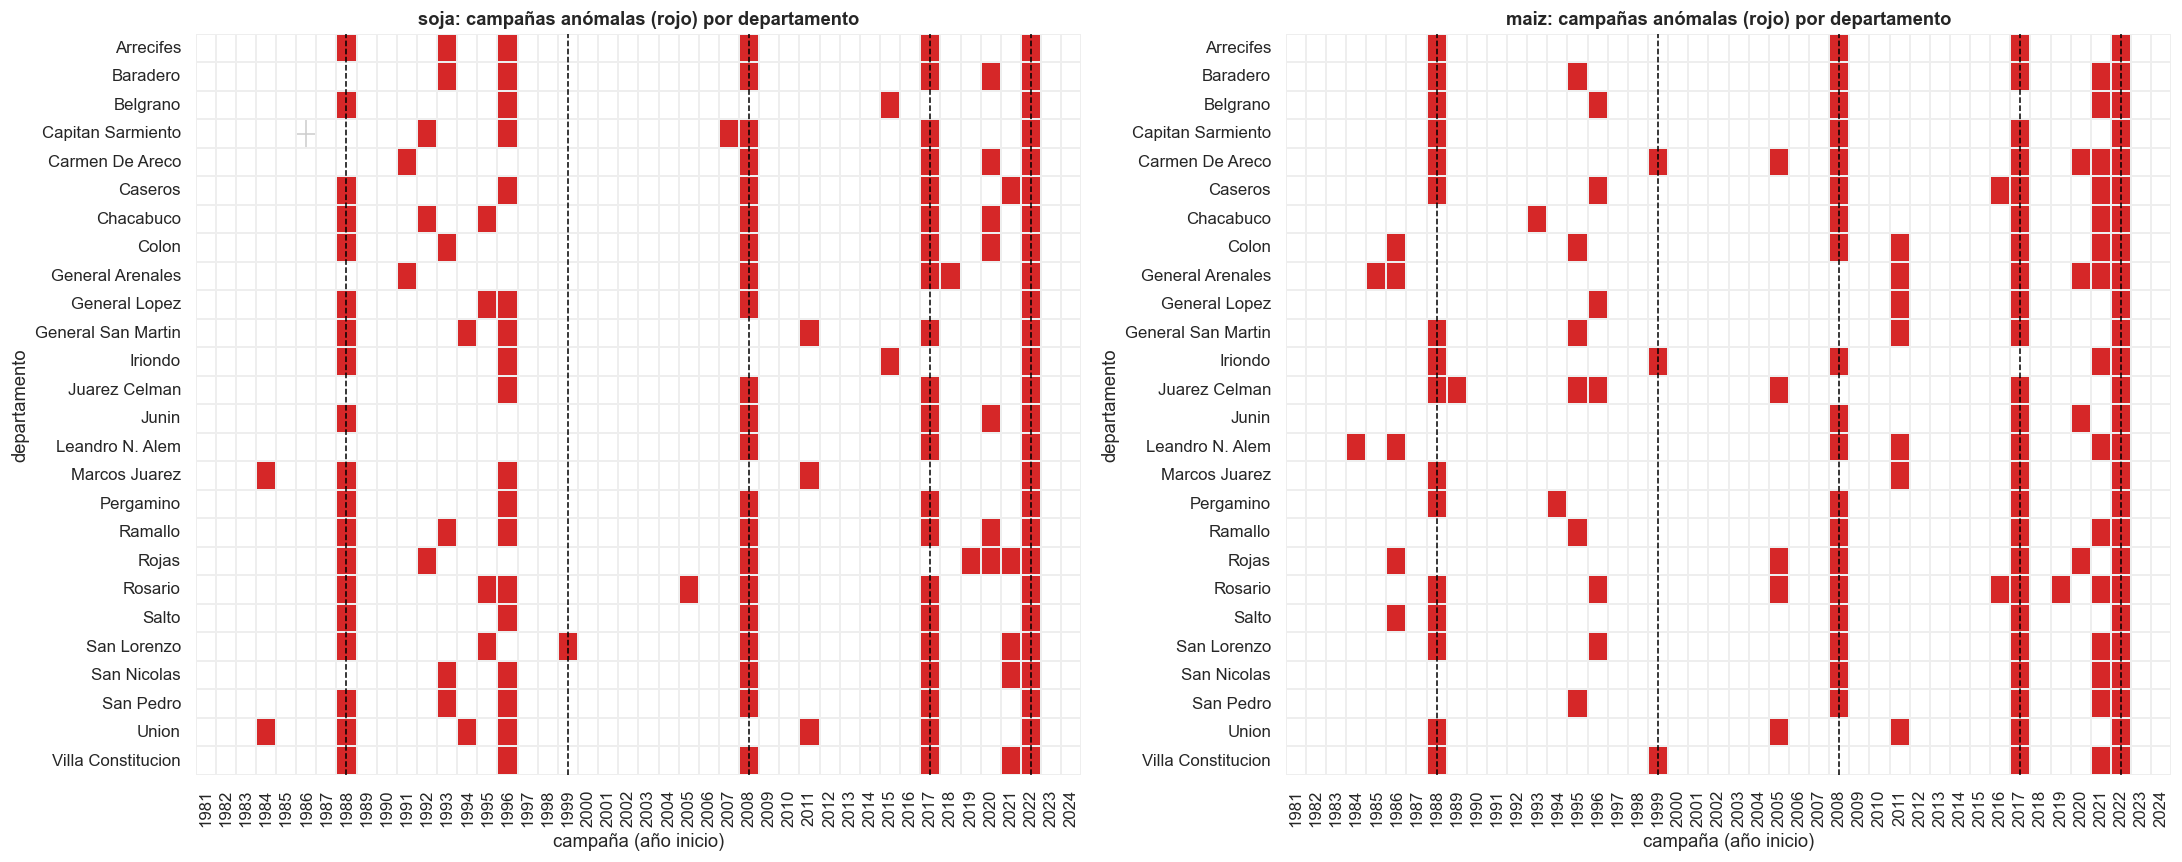

In [12]:
# Heatmap departamento × campaña: normal (blanco) vs anómala (rojo)
CAMP_CONOCIDAS = {1988: "1988/89", 1999: "1999/00", 2008: "2008/09", 2017: "2017/18", 2022: "2022/23"}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, cult in zip(axes, ["soja", "maiz"]):
    piv = (df[df["cultivo"] == cult]
           .pivot_table(index="departamento", columns="campania_inicio",
                        values="es_anomala", aggfunc="max"))
    sns.heatmap(piv.astype(float), cmap=["white", ANOM_COLORS["anomala"]],
                vmin=0, vmax=1, cbar=False, linewidths=.3, linecolor="#eee", ax=ax)
    cols = list(piv.columns)
    for y, lab in CAMP_CONOCIDAS.items():
        if y in cols:
            ax.axvline(cols.index(y) + 0.5, color="black", ls="--", lw=1)
    ax.set_title(f"{cult}: campañas anómalas (rojo) por departamento")
    ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("departamento")
plt.tight_layout(); plt.show()

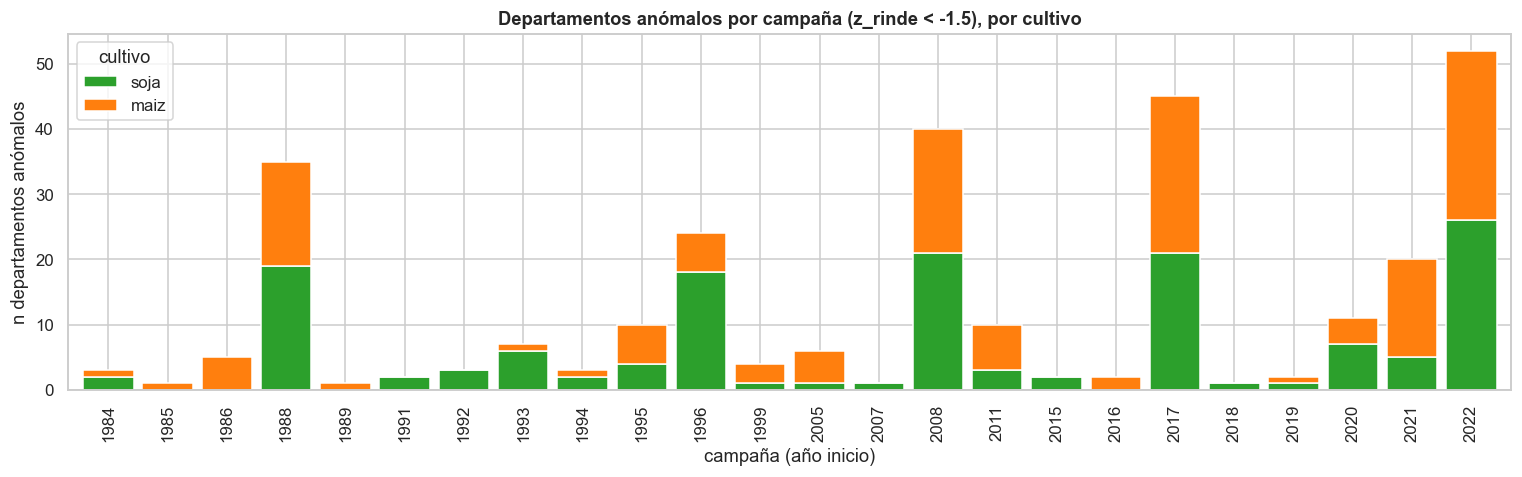

In [13]:
# Anomalías por campaña (criterio único z_rinde < -1.5), desglosado por cultivo
cnt = (df[df["es_anomala"]]
       .groupby(["campania_inicio", "cultivo"]).size()
       .unstack("cultivo", fill_value=0)
       .reindex(columns=["soja", "maiz"], fill_value=0))

fig, ax = plt.subplots(figsize=(14, 4.5))
cnt.plot.bar(stacked=True, color=[CROP_COLORS[c] for c in cnt.columns], ax=ax, width=.85)
ax.set_title("Departamentos anómalos por campaña (z_rinde < -1.5), por cultivo")
ax.set_xlabel("campaña (año inicio)"); ax.set_ylabel("n departamentos anómalos")
ax.legend(title="cultivo")
plt.tight_layout(); plt.show()


> **Lectura:** con el criterio único `z_rinde < −1.5`, las campañas más anómalas coinciden
> con las sequías conocidas (1988/89, 2008/09, 2017/18, 2022/23) y el etiquetado ya no
> depende de la fase ENSO. Esto mejora la especificidad del ground truth respecto del criterio
> doble previo. El ONI sigue disponible como feature de entrada para el AE.


In [14]:
# Tabla resumen: top 10 campañas más anómalas
resumen = (df.groupby("campania_inicio")
           .agg(n_anomalos=("es_anomala", "sum"),
                n_total=("es_anomala", "size"),
                oni_mean=("oni_mean_octfeb", "first"),
                z_rinde_mean=("z_rinde", "mean"))
           .assign(pct_anomalos=lambda t: (t["n_anomalos"] / t["n_total"] * 100).round(1))
           .sort_values("pct_anomalos", ascending=False))
print("Top 10 campañas más anómalas:")
display(resumen.head(10).round(2))

Top 10 campañas más anómalas:


,n_anomalos,n_total,oni_mean,z_rinde_mean,pct_anomalos
campania_inicio,,,,,
2022,52,52,-0.67,-3.49,100.0
2017,45,52,-0.74,-2.74,86.5
2008,40,52,-0.65,-3.88,76.9
1988,35,52,-1.65,-2.13,67.3
1996,24,52,-0.44,-1.13,46.2
2021,20,52,-0.83,-1.39,38.5
2020,11,52,-1.02,-0.84,21.2
1995,10,52,-0.92,-0.26,19.2
2011,10,52,-0.84,-0.92,19.2


### 2.2 Definición del train set del AE

El AE se entrena **solo sobre campañas normales** dentro del split train. Se excluyen además las campañas train donde más del 30% de los departamentos son anómalos — esas campañas tienen señal climática atípica que el AE no debe aprender como "normal".

In [15]:
# Campañas de train con >30% deptos anómalos -> excluir del entrenamiento del AE
train_camp = df[df["split"] == "train"].groupby("campania_inicio")["es_anomala"].mean()
excluidas  = sorted(train_camp[train_camp > 0.30].index.tolist())

print("Campañas excluidas del train del AE (>30% deptos anómalos):")
print(" ", [f"{y}/{str(y+1)[-2:]}" for y in excluidas] or "ninguna")

n_train_normal = df[(df["split"] == "train") & (~df["es_anomala"])
                    & (~df["campania_inicio"].isin(excluidas))].shape[0]
print(f"\nFilas disponibles para el train del AE (normales, sin campañas excluidas): {n_train_normal}")

Campañas excluidas del train del AE (>30% deptos anómalos):
  ['1988/89', '1996/97', '2008/09', '2017/18']

Filas disponibles para el train del AE (normales, sin campañas excluidas): 1655


---
## 3. Espacio de features del AE

El AE recibe como input las **49 variables NASA POWER** (7 variables × 7 meses sep–mar) más el `oni_mean_octfeb`. Esta sección responde tres preguntas de diseño:

1. ¿Cuánta redundancia hay entre las features? → orienta el **tamaño del cuello de botella**.
2. ¿Cuánta dimensionalidad real existe? → orienta si conviene aplicar **PCA pre-AE**.
3. ¿Las campañas anómalas son distinguibles en este espacio? → valida la **factibilidad del detector**.

> Toda estadística (medias para imputación, PCA) se calcula solo sobre train.

In [16]:
# Función de escalado: z-score usando solo estadísticas de train
def escalar_con_train(cols):
    """z-score fit en train, transform en todo el panel. Imputa NaN con la media de train."""
    tr   = df.loc[df["split"] == "train", cols]
    mean = tr.mean(); std = tr.std().replace(0, 1)
    X    = (df[cols].fillna(mean) - mean) / std
    return X, mean, std

### 3.1 Correlación entre las 49 features NASA

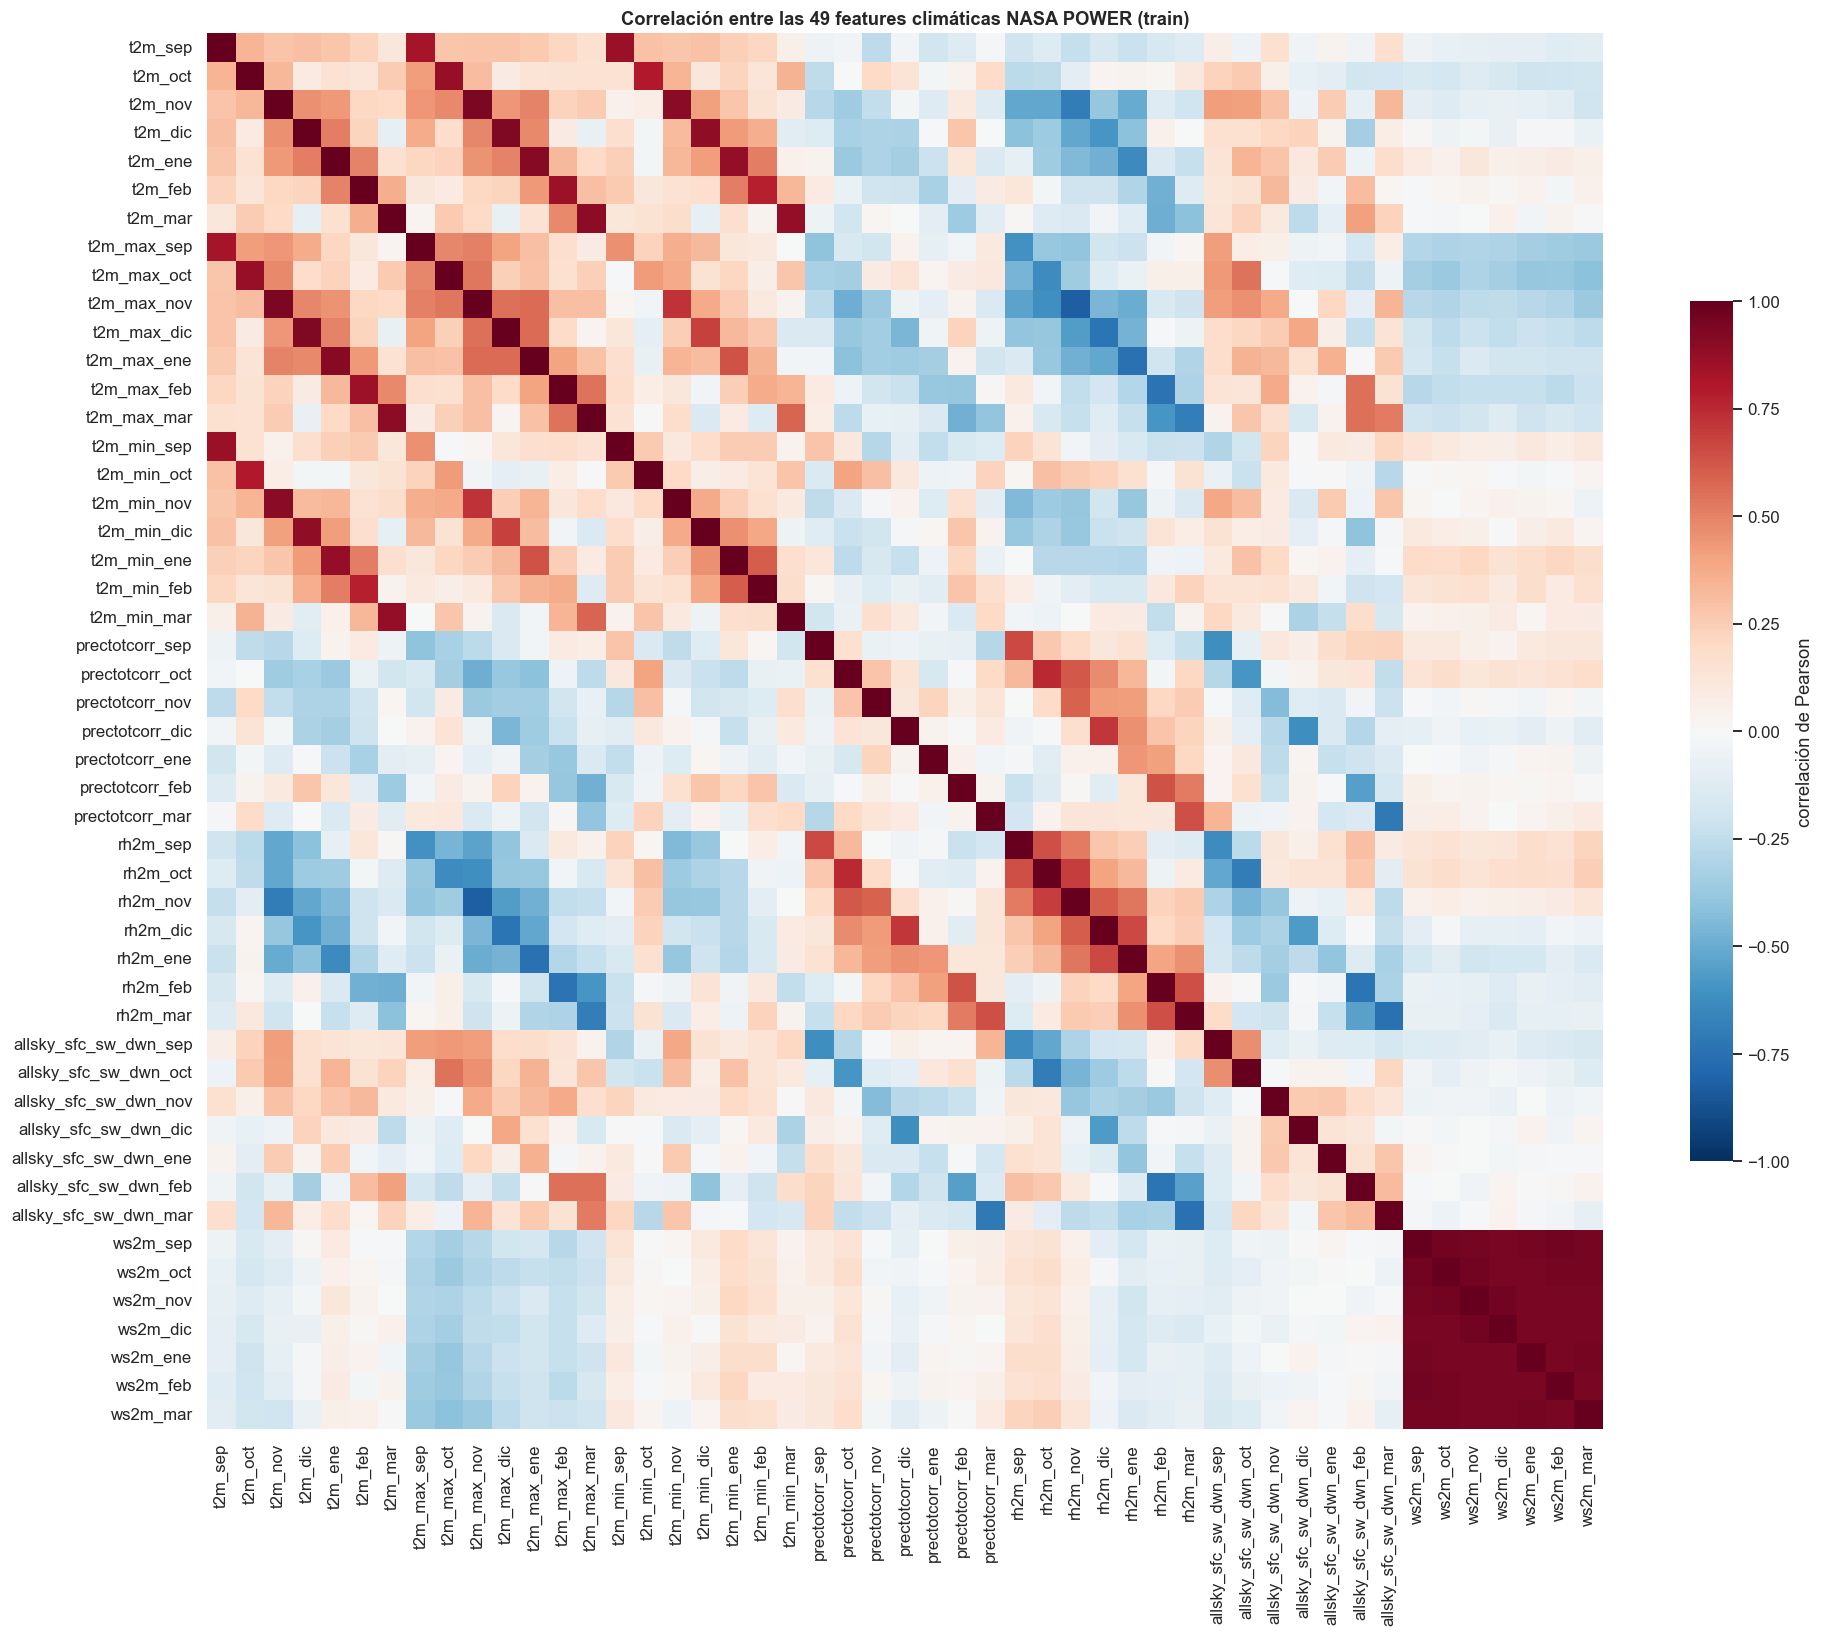

Top 10 pares con |corr| > 0.90:
  ws2m_oct                     ~ ws2m_nov                      r=0.966
  ws2m_sep                     ~ ws2m_feb                      r=0.966
  ws2m_sep                     ~ ws2m_oct                      r=0.963
  ws2m_nov                     ~ ws2m_dic                      r=0.962
  ws2m_oct                     ~ ws2m_feb                      r=0.960
  ws2m_ene                     ~ ws2m_mar                      r=0.960
  ws2m_sep                     ~ ws2m_mar                      r=0.958
  ws2m_oct                     ~ ws2m_mar                      r=0.958
  ws2m_sep                     ~ ws2m_nov                      r=0.957
  ws2m_sep                     ~ ws2m_ene                      r=0.957

Correlación |r| promedio INTRA-variable: 0.346
Correlación |r| promedio INTER-variable: 0.193


In [17]:
# Matriz de correlación (solo train, solo filas con rinde válido)
mask_tr = (df["split"] == "train") & df[TARGET].notna()
corr = df.loc[mask_tr, NASA_COLS].corr()

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(corr, cmap="RdBu_r", vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": .6, "label": "correlación de Pearson"}, ax=ax)
ax.set_title("Correlación entre las 49 features climáticas NASA POWER (train)")
plt.tight_layout(); plt.show()

# Redundancia extrema: pares con r > 0.90
cc    = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
altos = cc[cc > 0.90].sort_values(ascending=False)
print("Top 10 pares con |corr| > 0.90:")
for (a, b), v in altos.head(10).items():
    print(f"  {a:28s} ~ {b:28s}  r={v:.3f}")

# Correlación intra-variable vs inter-variable
def bloque(col): return col.rsplit("_", 1)[0]
bloques = {c: bloque(c) for c in NASA_COLS}
intra, inter = [], []
cm = corr.abs()
for i, a in enumerate(NASA_COLS):
    for b in NASA_COLS[i + 1:]:
        (intra if bloques[a] == bloques[b] else inter).append(cm.loc[a, b])
print(f"\nCorrelación |r| promedio INTRA-variable: {np.mean(intra):.3f}")
print(f"Correlación |r| promedio INTER-variable: {np.mean(inter):.3f}")

### 3.2 PCA: dimensionalidad real del espacio climático

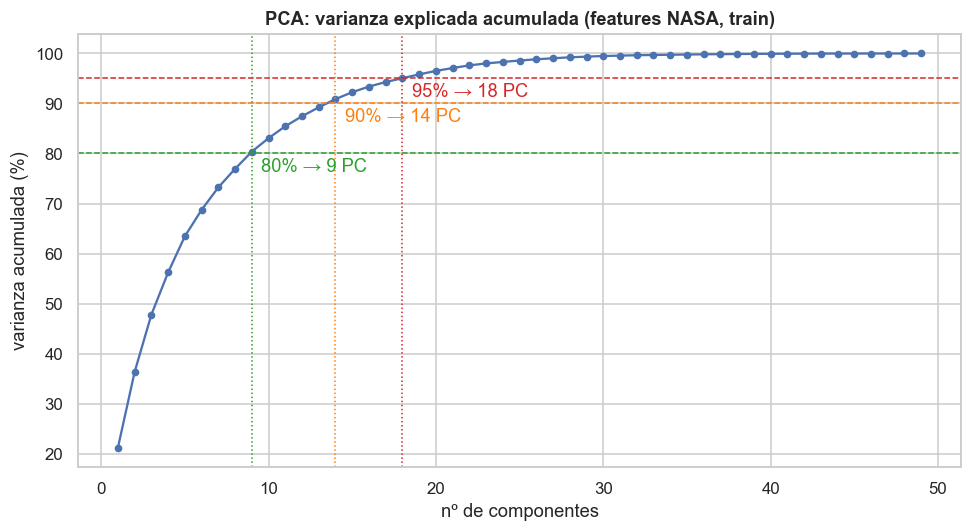

Componentes para 80/90/95% de varianza: 9 / 14 / 18
→ Cuello de botella sugerido para el AE: entre 7 y 14 neuronas.


In [18]:
X_nasa, _, _ = escalar_con_train(NASA_COLS)
X_nasa_train = X_nasa[df["split"] == "train"].values

pca_full = PCA(random_state=RANDOM_STATE).fit(X_nasa_train)
var_acum = np.cumsum(pca_full.explained_variance_ratio_) * 100
n80, n90, n95 = [int(np.argmax(var_acum >= t) + 1) for t in (80, 90, 95)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(var_acum) + 1), var_acum, marker="o", ms=4)
for t, n, c in [(80, n80, "#2ca02c"), (90, n90, "#ff7f0e"), (95, n95, "#d62728")]:
    ax.axhline(t, color=c, ls="--", lw=1)
    ax.axvline(n, color=c, ls=":",  lw=1)
    ax.annotate(f"{t}% → {n} PC", (n, t), textcoords="offset points", xytext=(6, -12), color=c)
ax.set_title("PCA: varianza explicada acumulada (features NASA, train)")
ax.set_xlabel("nº de componentes"); ax.set_ylabel("varianza acumulada (%)")
plt.tight_layout(); plt.show()

print(f"Componentes para 80/90/95% de varianza: {n80} / {n90} / {n95}")
print(f"→ Cuello de botella sugerido para el AE: entre {n90//2} y {n90} neuronas.")

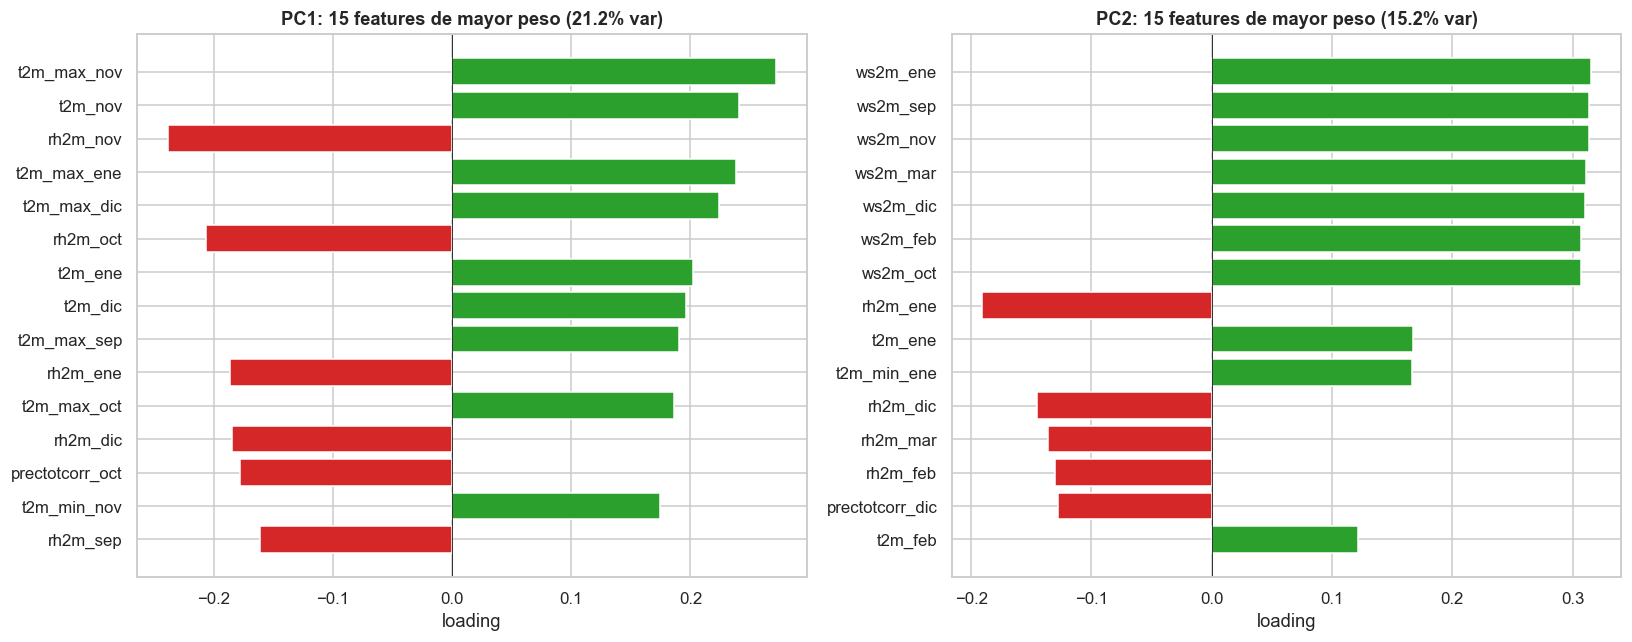

In [19]:
# Loadings PC1 y PC2: qué variables dominan cada componente (top 15 por |peso|)
load = pd.DataFrame(pca_full.components_[:2].T, index=NASA_COLS, columns=["PC1", "PC2"])
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    top = load[pc].reindex(load[pc].abs().sort_values(ascending=False).index).head(15)[::-1]
    ax.barh(top.index, top.values,
            color=["#d62728" if v < 0 else "#2ca02c" for v in top.values])
    idx = ["PC1", "PC2"].index(pc)
    ax.set_title(f"{pc}: 15 features de mayor peso "
                 f"({pca_full.explained_variance_ratio_[idx]*100:.1f}% var)")
    ax.set_xlabel("loading"); ax.axvline(0, color="black", lw=.5)
plt.tight_layout(); plt.show()

### 3.3 Separabilidad: ¿las anómalas difieren climáticamente de las normales?

Test de Mann-Whitney U (no paramétrico) para las 8 features más relevantes agronómicamente.

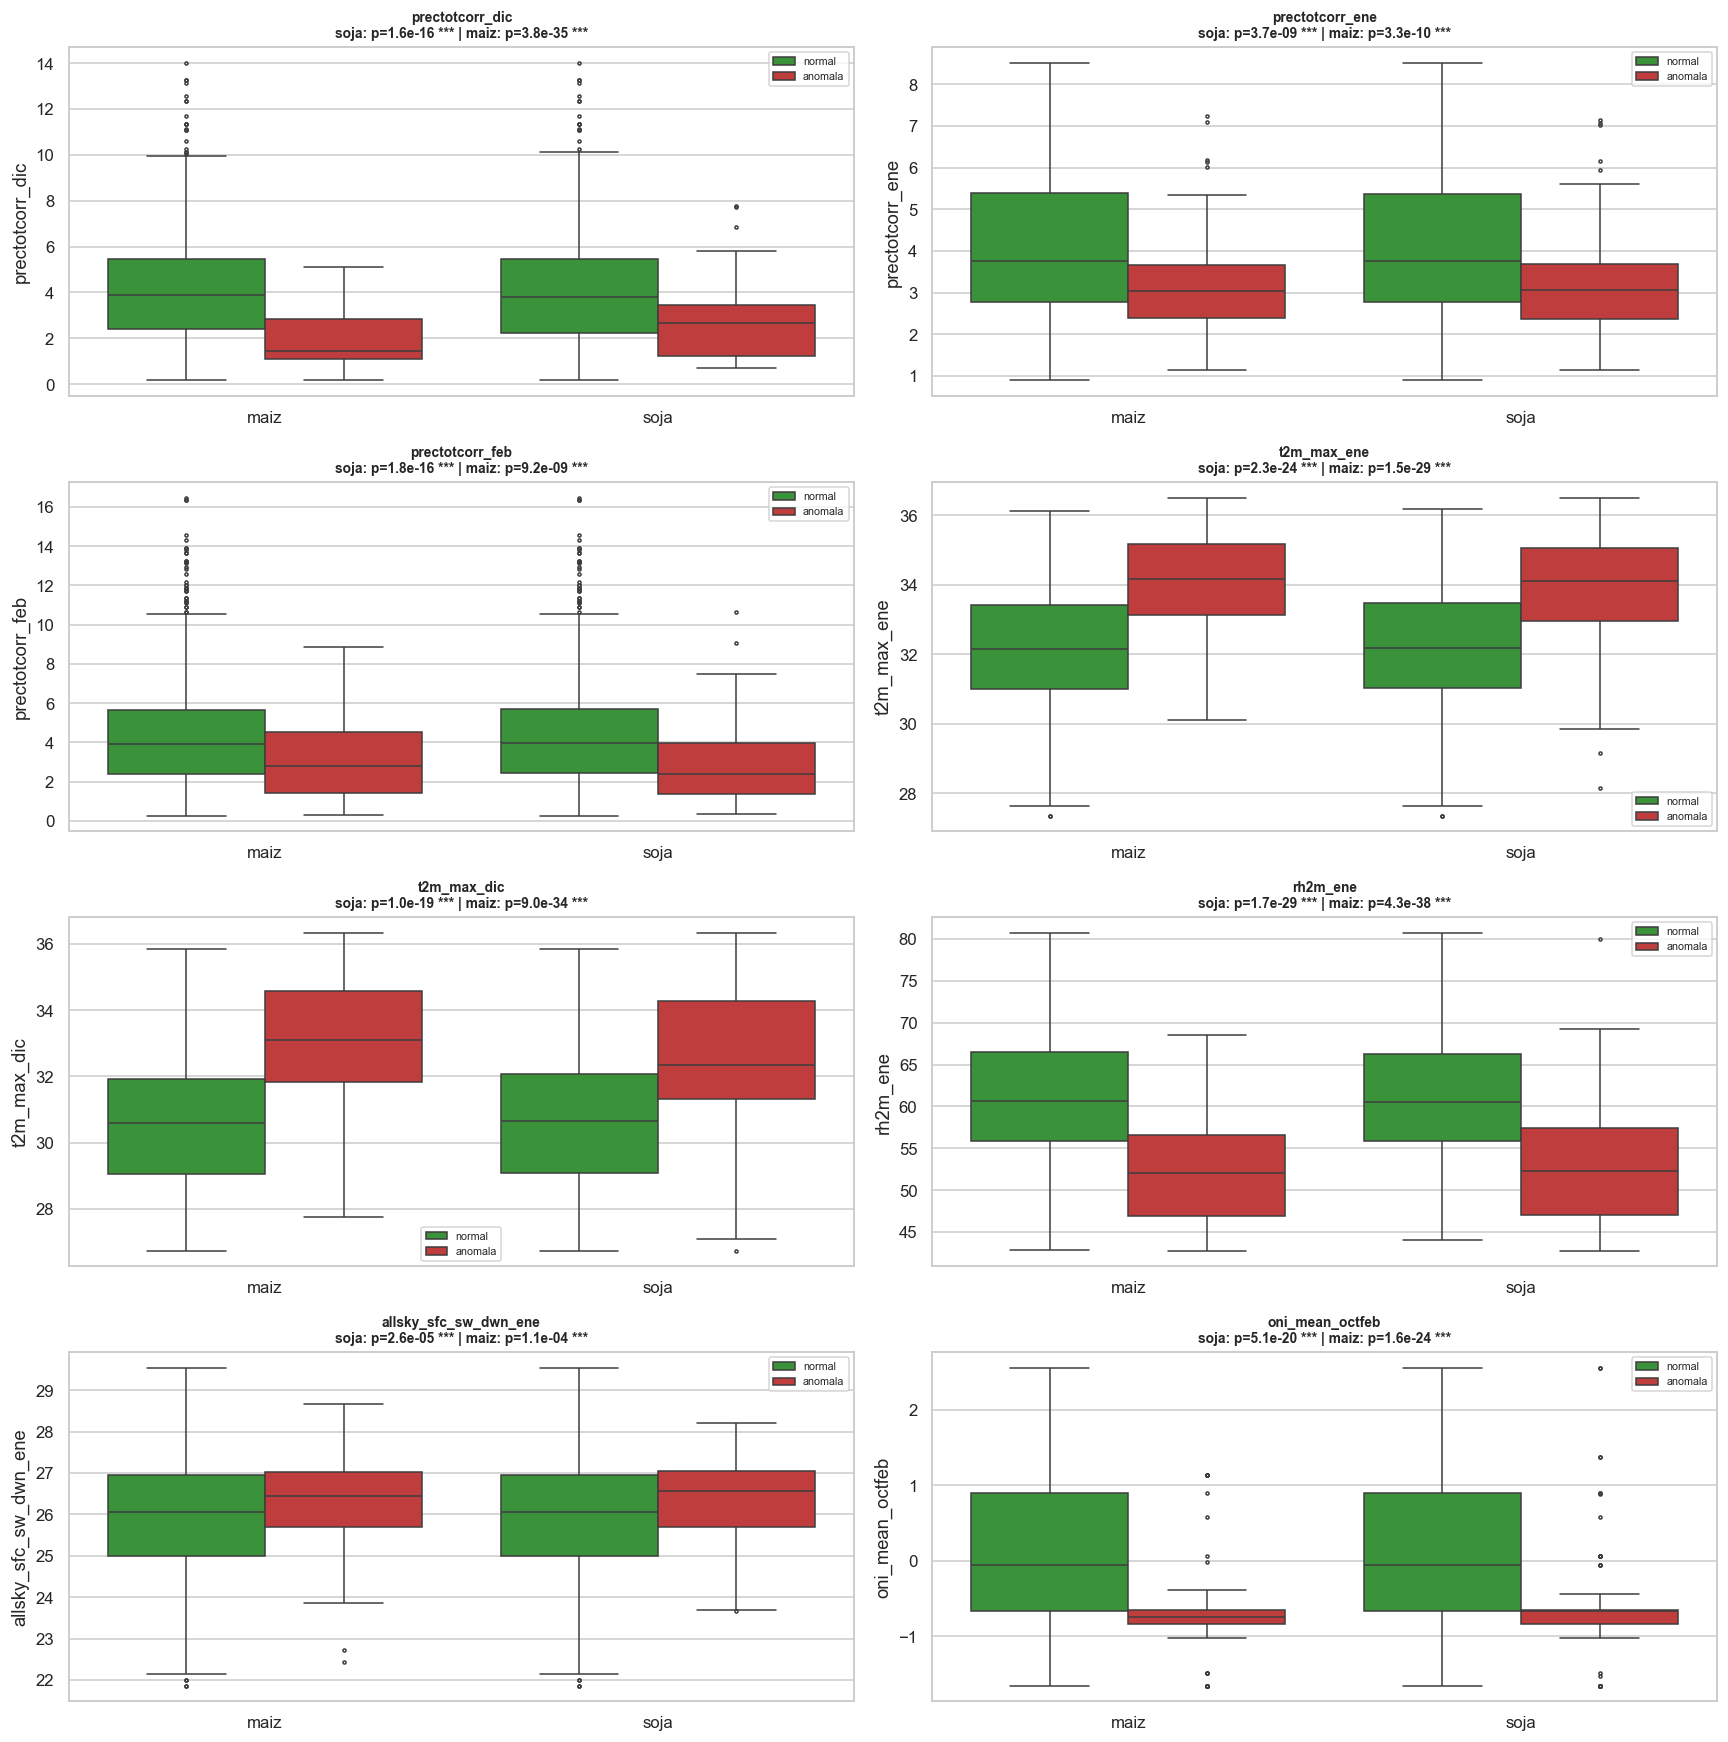

In [20]:
FEATS_CLAVE = ["prectotcorr_dic", "prectotcorr_ene", "prectotcorr_feb", "t2m_max_ene",
               "t2m_max_dic", "rh2m_ene", "allsky_sfc_sw_dwn_ene", "oni_mean_octfeb"]

def estrellas(p):
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "ns"

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
for ax, feat in zip(axes.ravel(), FEATS_CLAVE):
    sns.boxplot(data=df, x="cultivo", y=feat, hue="label_anomalia",
                hue_order=["normal", "anomala"], palette=ANOM_COLORS, ax=ax, fliersize=2)
    txt = []
    for cult in ["soja", "maiz"]:
        sub = df[df["cultivo"] == cult]
        a = sub.loc[sub["label_anomalia"] == "normal",  feat].dropna()
        b = sub.loc[sub["label_anomalia"] == "anomala", feat].dropna()
        if len(a) > 5 and len(b) > 5:
            p = mannwhitneyu(a, b).pvalue
            txt.append(f"{cult}: p={p:.1e} {estrellas(p)}")
    ax.set_title(f"{feat}\n" + " | ".join(txt), fontsize=9)
    ax.set_xlabel(""); ax.legend(fontsize=7, loc="best")
plt.tight_layout(); plt.show()

### 3.4 Perfiles mensuales: ¿cuándo diverge la señal climática?

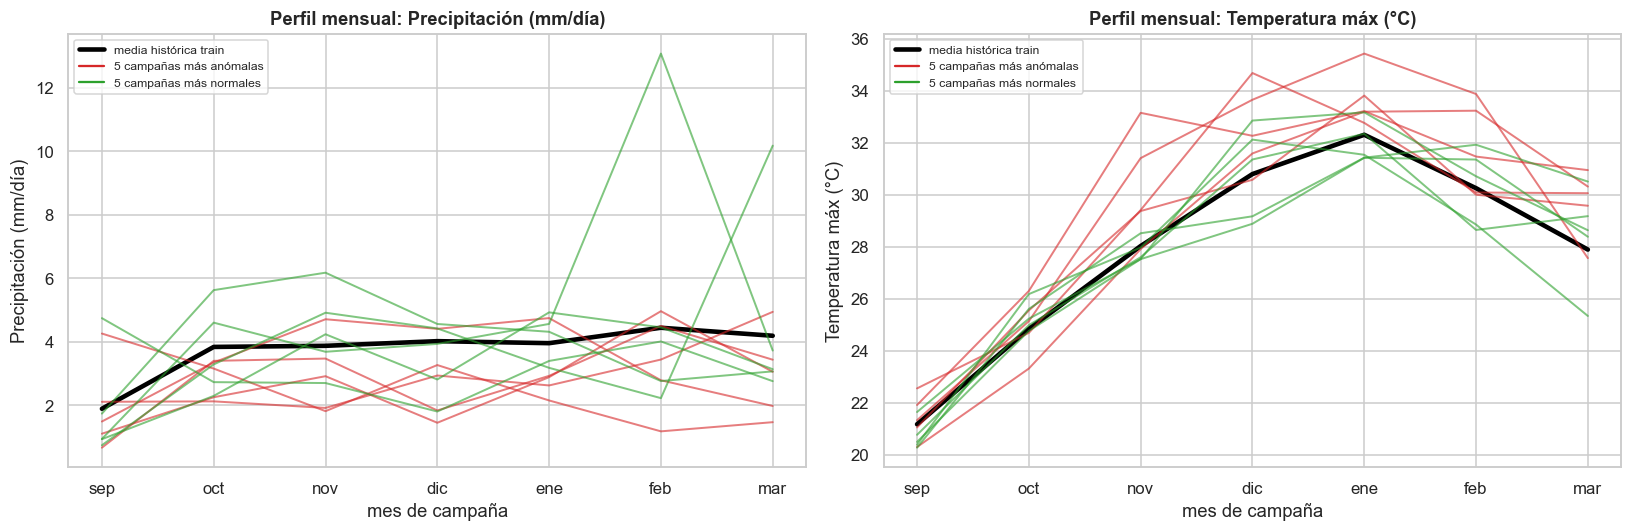

In [21]:
# 5 campañas más anómalas vs 5 más normales (train), promediando sobre todos los deptos
score_camp = df[df["split"] == "train"].groupby("campania_inicio")["es_anomala"].mean()
top_anom   = score_camp.sort_values(ascending=False).head(5).index.tolist()
top_norm   = score_camp.sort_values().head(5).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (var, label) in zip(axes, [("prectotcorr", "Precipitación (mm/día)"),
                                    ("t2m_max", "Temperatura máx (°C)")]):
    cols_var = nasa_var_cols(var)
    hist = df[df["split"] == "train"][cols_var].mean()
    ax.plot(MESES, hist.values, color="black", lw=3, label="media histórica train")
    for y in top_anom:
        s = df[df["campania_inicio"] == y][cols_var].mean()
        ax.plot(MESES, s.values, color="#d62728", alpha=.6, lw=1.3)
    for y in top_norm:
        s = df[df["campania_inicio"] == y][cols_var].mean()
        ax.plot(MESES, s.values, color="#2ca02c", alpha=.6, lw=1.3)
    ax.plot([], [], color="#d62728", label="5 campañas más anómalas")
    ax.plot([], [], color="#2ca02c", label="5 campañas más normales")
    ax.set_title(f"Perfil mensual: {label}")
    ax.set_xlabel("mes de campaña"); ax.set_ylabel(label); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 4. Proyecciones 2D del espacio climático

Reducción de dimensionalidad para validar visualmente la separabilidad normal/anómala y detectar posible distribution shift entre splits.

**Input:** 49 features NASA + `oni_mean_octfeb`, normalizadas con z-score de train.  
**Colores:** verde = normal · rojo = anómala. **Marcadores:** círculo = soja · triángulo = maíz.

> t-SNE es estocástico y no preserva distancias globales. Usarlo solo para exploración visual, no para medir separabilidad.

In [22]:
# Preparación común para las tres proyecciones
FEAT_PROJ = NASA_COLS + ["oni_mean_octfeb"]
X_proj, _, _ = escalar_con_train(FEAT_PROJ)

is_tr   = (df["split"] == "train").values
Xtr     = X_proj[is_tr].values
lab_tr  = df.loc[is_tr, "label_anomalia"].values
crop_tr = df.loc[is_tr, "cultivo"].values
camp_tr = df.loc[is_tr, "campania_inicio"].values

MARCADOR     = {"soja": "o", "maiz": "^"}
CAMP_EXTREMAS = [1988, 1999, 2008, 2017]

def scatter_2d(ax, emb, labels, crops, title):
    for cult in ["soja", "maiz"]:
        for lab in ["normal", "anomala"]:
            m = (crops == cult) & (labels == lab)
            ax.scatter(emb[m, 0], emb[m, 1], s=18, alpha=.6,
                       c=ANOM_COLORS[lab], marker=MARCADOR[cult],
                       label=f"{cult}-{lab}", edgecolors="none")
    ax.set_title(title); ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")

def anotar_campanas(ax, emb, camp):
    for y in CAMP_EXTREMAS:
        m = camp == y
        if m.any():
            cx, cy = emb[m, 0].mean(), emb[m, 1].mean()
            ax.annotate(f"{y}/{str(y+1)[-2:]}", (cx, cy), fontsize=8, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=.7))

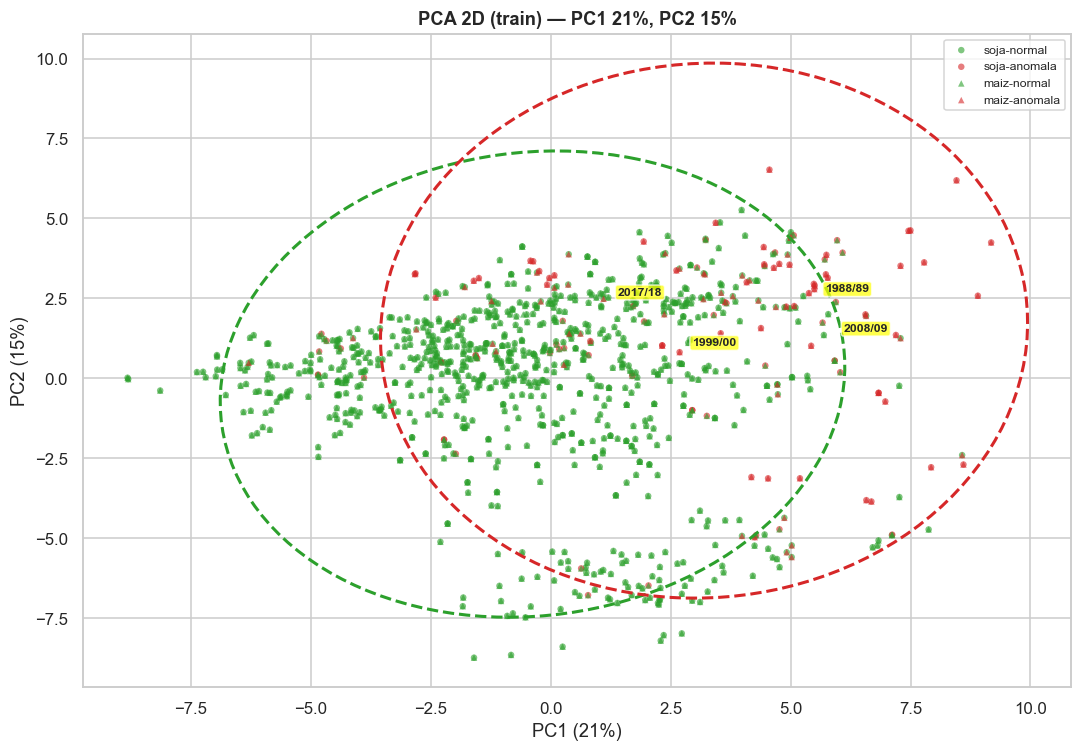

In [23]:
# PCA 2D con elipses de confianza 95%
def elipse_confianza(ax, x, y, color, n_std=2.4477):  # chi2 95%, 2 gl
    cov  = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    ang  = np.degrees(np.arctan2(*vecs[:, 1][::-1]))
    w, h = 2 * n_std * np.sqrt(vals)
    e = Ellipse((x.mean(), y.mean()), w, h, angle=ang, fc="none", ec=color, lw=2, ls="--")
    ax.add_patch(e)

pca2    = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xtr)
emb_pca = pca2.transform(Xtr)
vr      = pca2.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))
scatter_2d(ax, emb_pca, lab_tr, crop_tr, f"PCA 2D (train) — PC1 {vr[0]:.0f}%, PC2 {vr[1]:.0f}%")
for lab in ["normal", "anomala"]:
    m = lab_tr == lab
    elipse_confianza(ax, emb_pca[m, 0], emb_pca[m, 1], ANOM_COLORS[lab])
anotar_campanas(ax, emb_pca, camp_tr)
ax.set_xlabel(f"PC1 ({vr[0]:.0f}%)"); ax.set_ylabel(f"PC2 ({vr[1]:.0f}%)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

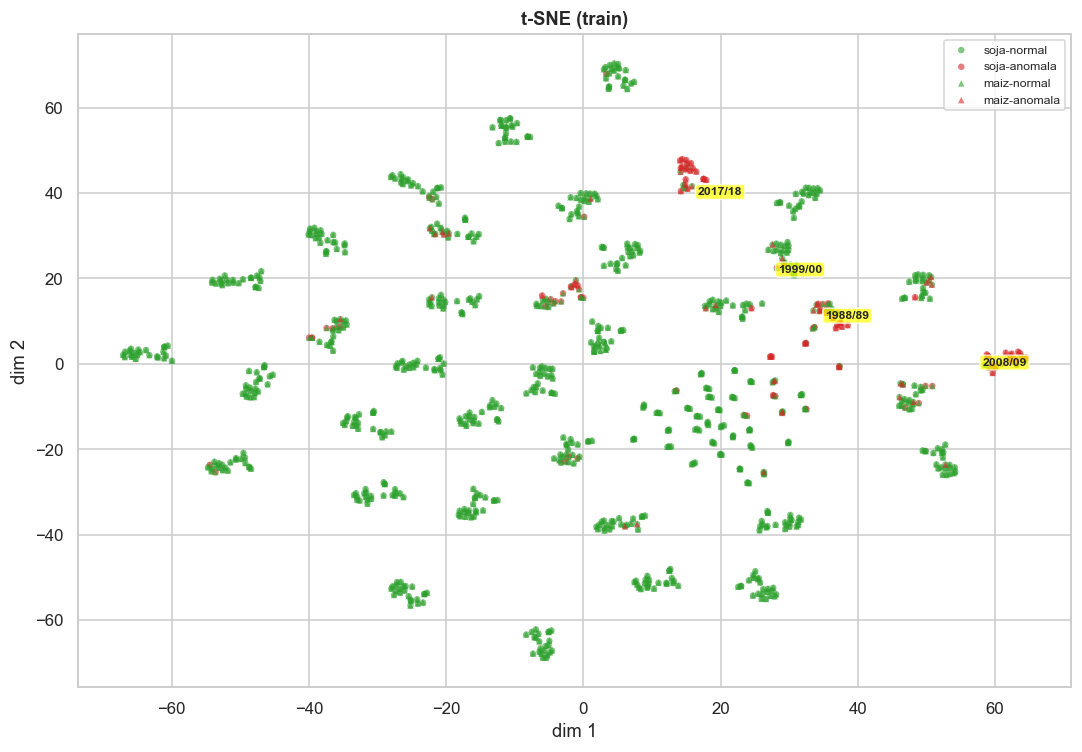

In [24]:
# t-SNE (solo train)
tsne     = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=RANDOM_STATE, init="pca")
emb_tsne = tsne.fit_transform(Xtr)

fig, ax = plt.subplots(figsize=(10, 7))
scatter_2d(ax, emb_tsne, lab_tr, crop_tr, "t-SNE (train)")
anotar_campanas(ax, emb_tsne, camp_tr)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

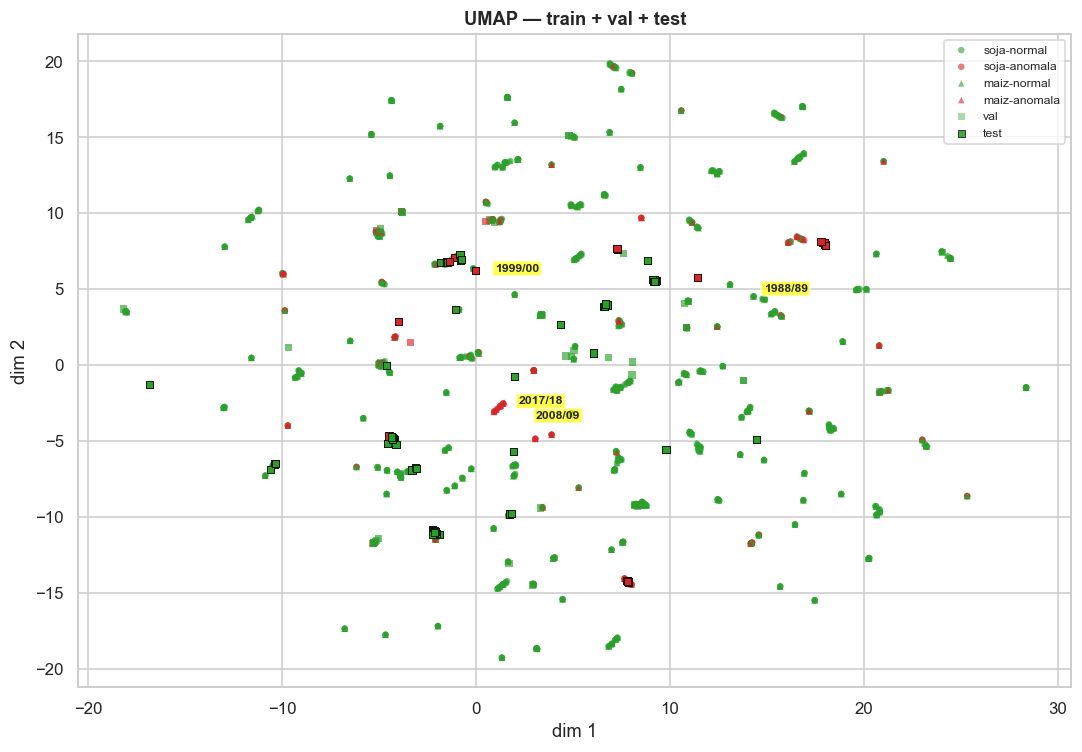

Cuadrados = val (transparente) y test (borde negro). Sin shift visible → el AE generaliza dentro del espacio conocido.


In [25]:
# UMAP: fit en train, transform en val y test (distribution shift)
reducer     = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=RANDOM_STATE)
emb_umap_tr = reducer.fit_transform(Xtr)

fig, ax = plt.subplots(figsize=(10, 7))
scatter_2d(ax, emb_umap_tr, lab_tr, crop_tr, "UMAP — train + val + test")
anotar_campanas(ax, emb_umap_tr, camp_tr)
for split, alpha, edge in [("val", 0.4, "none"), ("test", 0.9, "black")]:
    m    = (df["split"] == split).values
    emb  = reducer.transform(X_proj[m].values)
    cols = df.loc[m, "label_anomalia"].map(ANOM_COLORS).values
    ax.scatter(emb[:, 0], emb[:, 1], s=22, alpha=alpha, c=cols,
               edgecolors=edge, linewidths=.5, marker="s", label=split)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Cuadrados = val (transparente) y test (borde negro). Sin shift visible → el AE generaliza dentro del espacio conocido.")

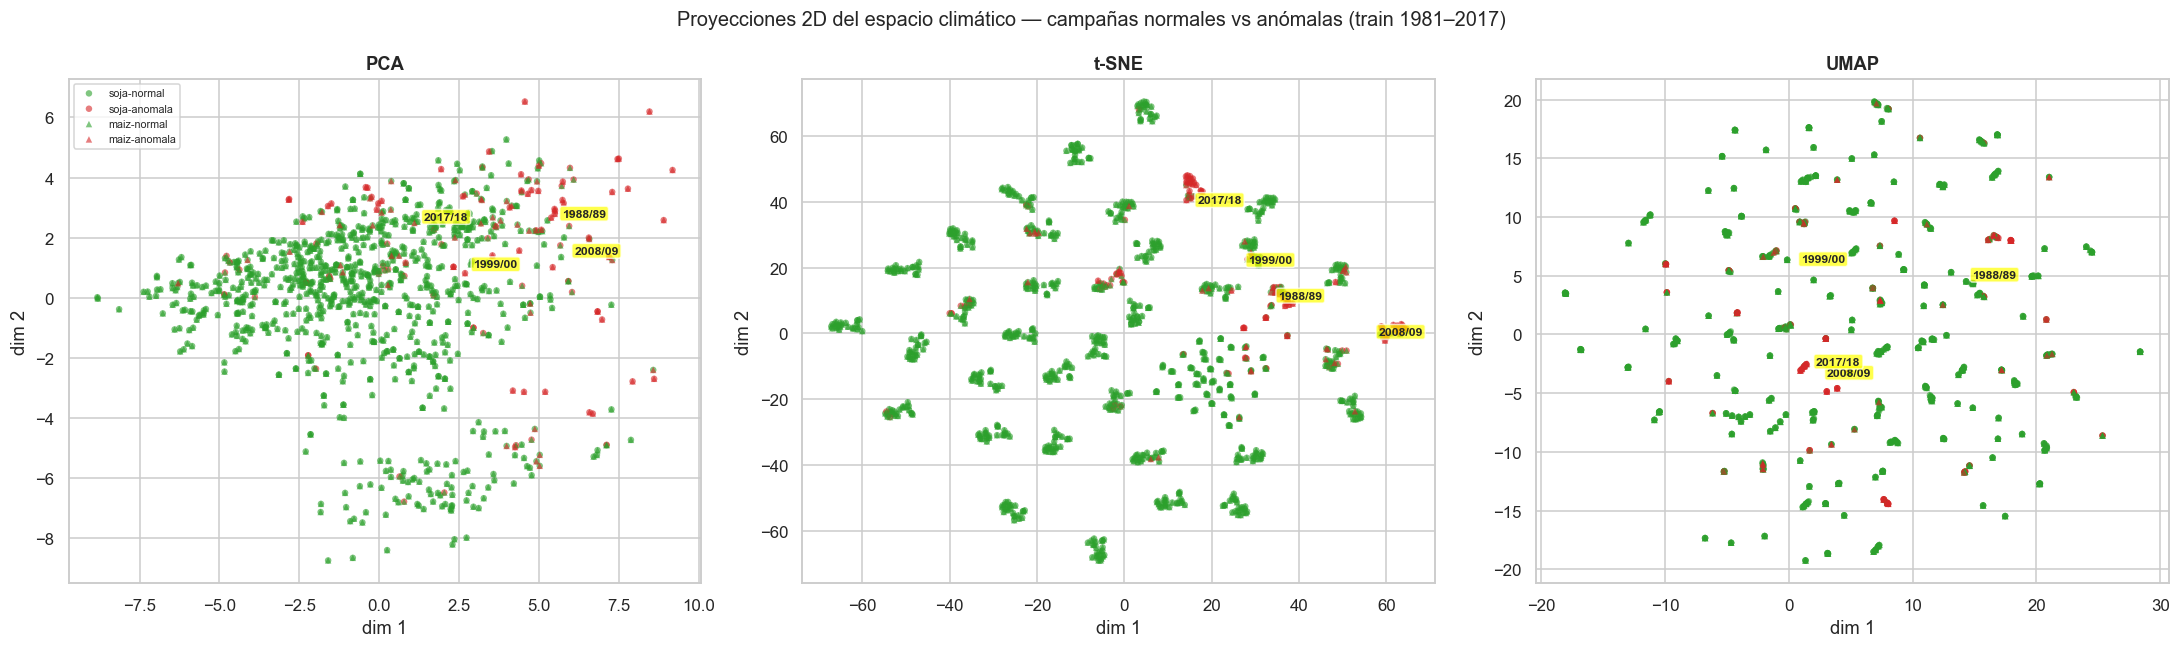

In [26]:
# Panel comparativo: PCA · t-SNE · UMAP (solo train)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, emb, name in [(axes[0], emb_pca, "PCA"),
                       (axes[1], emb_tsne, "t-SNE"),
                       (axes[2], emb_umap_tr, "UMAP")]:
    scatter_2d(ax, emb, lab_tr, crop_tr, name)
    anotar_campanas(ax, emb, camp_tr)
axes[0].legend(fontsize=7)
fig.suptitle("Proyecciones 2D del espacio climático — campañas normales vs anómalas (train 1981–2017)",
             fontsize=13)
plt.tight_layout(); plt.show()

---
## 5. Variabilidad departamental — justificación de la normalización por departamento

Si la diferencia climática **estructural entre departamentos** es comparable a la variabilidad **interanual dentro de un departamento**, una normalización global mezclaría la firma climática del lugar con la anomalía de campaña. El AE identificaría a un departamento naturalmente seco como "anómalo" cuando simplemente es seco por su geografía.

prectotcorr_ene: variación ENTRE deptos = 0.59 mm/día | variación interanual DENTRO de un depto = 1.64 mm/día
t2m_max_ene: variación ENTRE deptos = 2.63 °C | variación interanual DENTRO de un depto = 1.57 °C


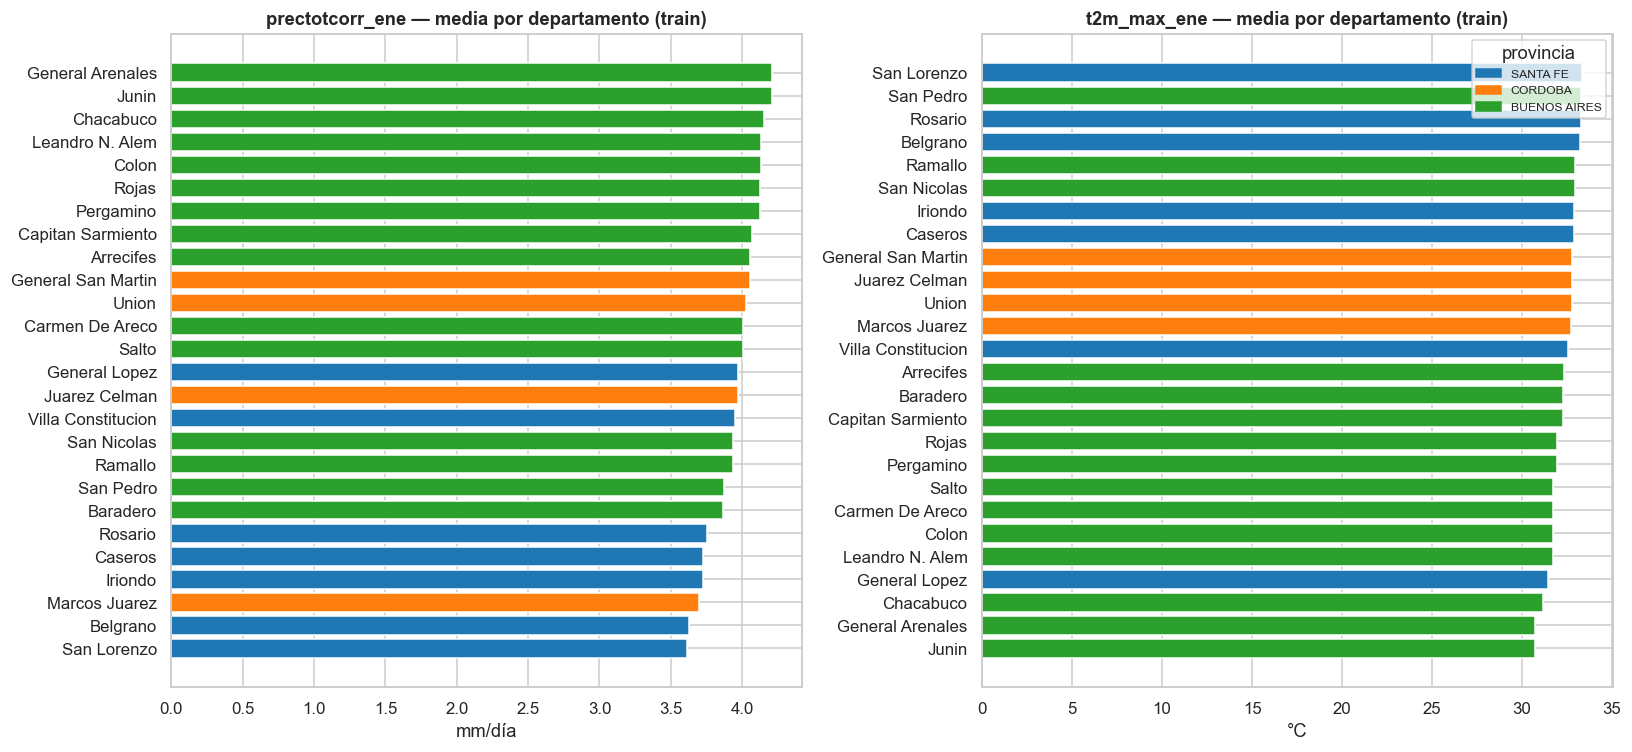


Si variación entre deptos ≥ variación interanual → normalizar por departamento, no globalmente.


In [27]:
tr = df[df["split"] == "train"]
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, (feat, unidad) in zip(axes, [("prectotcorr_ene", "mm/día"), ("t2m_max_ene", "°C")]):
    medias = tr.groupby(["departamento", "provincia"])[feat].mean().reset_index().sort_values(feat)
    ax.barh(medias["departamento"], medias[feat],
            color=[PROV_COLORS.get(p, "#888") for p in medias["provincia"]])
    ax.set_title(f"{feat} — media por departamento (train)")
    ax.set_xlabel(unidad)
    entre = medias[feat].max() - medias[feat].min()
    intra = tr.groupby("departamento")[feat].std().mean()
    print(f"{feat}: variación ENTRE deptos = {entre:.2f} {unidad} | variación interanual DENTRO de un depto = {intra:.2f} {unidad}")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in PROV_COLORS.values()]
axes[1].legend(handles, PROV_COLORS.keys(), title="provincia", fontsize=8)
plt.tight_layout(); plt.show()
print("\nSi variación entre deptos ≥ variación interanual → normalizar por departamento, no globalmente.")

### 5.1 Heterogeneidad de la señal clima–rinde por departamento

La correlación clima-rinde varía por departamento y cultivo, lo que orienta qué variables serán las más sensibles al error de reconstrucción del AE.

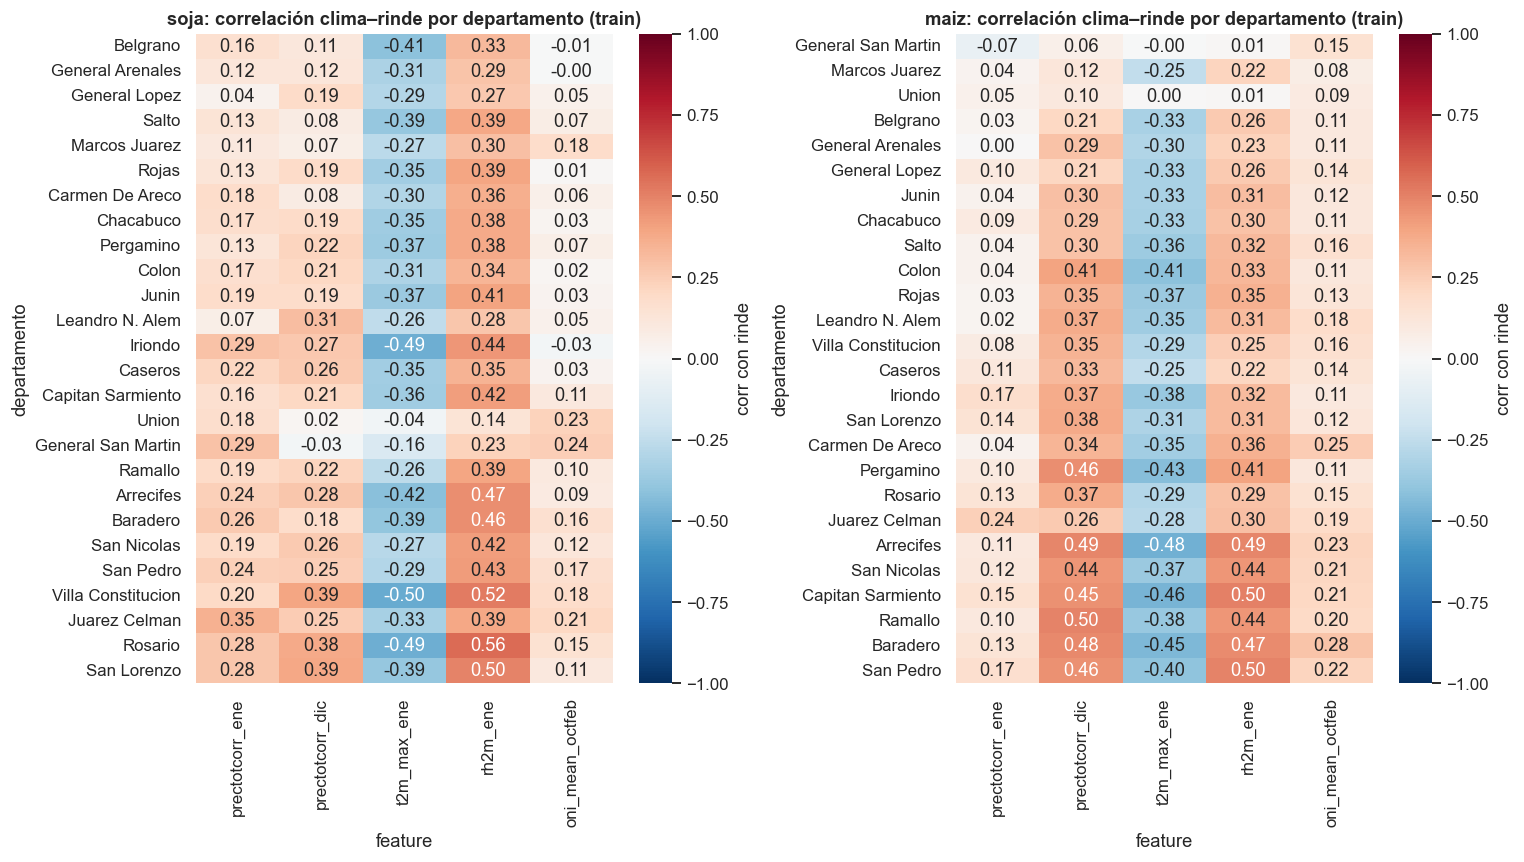

In [28]:
FEATS_CORR = ["prectotcorr_ene", "prectotcorr_dic", "t2m_max_ene", "rh2m_ene", "oni_mean_octfeb"]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, cult in zip(axes, ["soja", "maiz"]):
    sub = df[(df["split"] == "train") & (df["cultivo"] == cult)]
    filas = {}
    for dep, g in sub.groupby("departamento"):
        filas[dep] = [g[[f, TARGET]].corr().iloc[0, 1] for f in FEATS_CORR]
    cmat = pd.DataFrame(filas, index=FEATS_CORR).T
    cmat = cmat.loc[cmat.mean(axis=1).sort_values().index]
    sns.heatmap(cmat, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                annot=True, fmt=".2f", cbar_kws={"label": "corr con rinde"}, ax=ax)
    ax.set_title(f"{cult}: correlación clima–rinde por departamento (train)")
    ax.set_xlabel("feature"); ax.set_ylabel("departamento")
plt.tight_layout(); plt.show()

# EDA — Componente A: Detección de Anomalías en Campañas Agrícolas

Análisis exploratorio de `data/processed/panel_nucleo.parquet` (merge puro de 4 fuentes, sin feature engineering).

**Región núcleo pampeana** · 26 departamentos × soja y maíz · campañas 1981/82–2024/25

Este notebook es el análisis exploratorio orientado al **diseño e implementación del autoencoder (AE)** para la detección no supervisada de campañas anómalas (Componente A del sistema integrado).

El notebook sigue un hilo conductor en cuatro etapas:

1. **Contexto del panel** — estructura, faltantes y señal temporal del target  
2. **Ground truth proxy** — etiquetado formal de campañas anómalas (insumo de validación y filtro del train del AE)  
3. **Espacio de features del AE** — correlación, dimensionalidad y separabilidad normal/anómala  
4. **Variabilidad departamental** — justificación de la normalización por departamento  

Al final se exportan los tres artefactos que consume el notebook del autoencoder.

---

**Principios de diseño respetados en todo el notebook:**
- `rinde_kgha` y sus derivados **nunca** son features del AE — solo se usan para etiquetar y como filtro de filas válidas (sin leakage del target).
- Sin `dropna()` global — el NDVI es NaN estructural pre-2002 (MODIS). Los NaN se manejan localmente.
- Toda estadística de normalización se calcula **exclusivamente sobre train**.
- Soja y maíz se analizan por separado cuando sus escalas difieren (~2 700 vs ~6 700 kg/ha).

**Splits temporales:** `train` ≤ 2017 · `val` 2018–2020 · `test` 2021–2024 (incluye la sequía 2022/23).

---
## 6. Feature engineering CHIRPS — período crítico (sin leakage)

A partir de la serie diaria cruda `data/processed/chirps_diario.parquet` (departamento ×
fecha) derivamos features que capturan **cuándo** y **cuánto** llovió en la etapa crítica del
cultivo — lo que el promedio mensual de NASA POWER no resuelve. Todas las estandarizaciones
(SPI) usan media/desvío por departamento **calculados solo sobre train (≤ 2017)**.

| Feature | Definición | Ventana |
|---|---|---|
| `SPI_3_feb` | Precip acumulada Oct–Feb estandarizada vs. distribución histórica del depto | Oct(Y)–Feb(Y+1) |
| `SPI_6_feb` | Ídem, acumulando desde mayo | May(Y)–Feb(Y+1) |
| `dias_secos_consec_dic` | Máx. racha de días con < 1 mm en diciembre | Dic(Y) |
| `dias_secos_consec_ene` | Máx. racha de días con < 1 mm en enero | Ene(Y+1) |
| `precip_quincenal_critica` | Precip de la quincena crítica **por cultivo**: maíz VT/floración (16–31 dic), soja R1 (1–15 ene) | por cultivo |

> El SPI acá es una estandarización gaussiana del acumulado (z-score con parámetros de train),
> no un ajuste gamma completo; es leakage-safe e interpretable en desvíos estándar.


In [29]:
# ── Helpers CHIRPS ───────────────────────────────────────────────────────────
import unicodedata

def normalizar_nombre(s):
    """Misma normalización que el ETL, para que los deptos de CHIRPS matcheen el panel."""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))
    return " ".join(s.split()).title()

TRAIN_END = 2017  # estadísticos de SPI: solo campañas <= TRAIN_END

chirps_path = ROOT / "data" / "processed" / "chirps_diario.parquet"
daily = pd.read_parquet(chirps_path)
daily["fecha"] = pd.to_datetime(daily["fecha"])
daily["departamento"] = daily["departamento"].apply(normalizar_nombre)
daily["anio"] = daily["fecha"].dt.year
daily["mes"]  = daily["fecha"].dt.month

# Campaña extendida: May–Dic(Y)->Y ; Ene–Feb(Y+1)->Y ; resto (mar/abr)->NaN
def _camp_ext(mes, anio):
    if 5 <= mes <= 12: return anio
    if mes <= 2:       return anio - 1
    return np.nan
daily["camp_ext"] = [_camp_ext(m, a) for m, a in zip(daily["mes"], daily["anio"])]
ext = daily.dropna(subset=["camp_ext"]).copy()
ext["camp_ext"] = ext["camp_ext"].astype(int)

# ── Acumulados estacionales -> SPI estandarizado (parámetros de train) ────────
acc_of = (ext[ext["mes"].isin([10, 11, 12, 1, 2])]
          .groupby(["departamento", "camp_ext"])["precip_mm"].sum()
          .rename("acc_precip_oct_feb").reset_index())
acc_mf = (ext.groupby(["departamento", "camp_ext"])["precip_mm"].sum()
          .rename("acc_precip_may_feb").reset_index())
chirps_feats = acc_of.merge(acc_mf, on=["departamento", "camp_ext"]) \
                     .rename(columns={"camp_ext": "campania_inicio"})

def _estandarizar(feats, col_raw, col_out):
    tr = feats[feats["campania_inicio"] <= TRAIN_END]
    st = tr.groupby("departamento")[col_raw].agg(_m="mean", _s="std")
    feats = feats.merge(st, on="departamento", how="left")
    feats[col_out] = (feats[col_raw] - feats["_m"]) / feats["_s"].replace(0, np.nan)
    return feats.drop(columns=["_m", "_s"])

chirps_feats = _estandarizar(chirps_feats, "acc_precip_oct_feb", "SPI_3_feb")
chirps_feats = _estandarizar(chirps_feats, "acc_precip_may_feb", "SPI_6_feb")

# ── Rachas secas máximas (< 1 mm) en Dic(Y) y Ene(Y+1) ───────────────────────
def _max_racha_seca(precip, thresh=1.0):
    best = cur = 0
    for seco in (precip.values < thresh):
        cur = cur + 1 if seco else 0
        best = max(best, cur)
    return best

ds_dic = (daily[daily["mes"] == 12].sort_values(["departamento", "fecha"])
          .groupby(["departamento", "anio"])["precip_mm"].apply(_max_racha_seca)
          .rename("dias_secos_consec_dic").reset_index()
          .rename(columns={"anio": "campania_inicio"}))
ds_ene = (daily[daily["mes"] == 1].sort_values(["departamento", "fecha"])
          .groupby(["departamento", "anio"])["precip_mm"].apply(_max_racha_seca)
          .rename("dias_secos_consec_ene").reset_index())
ds_ene["campania_inicio"] = ds_ene["anio"] - 1
ds_ene = ds_ene.drop(columns="anio")

# ── Precip de la quincena crítica por cultivo ────────────────────────────────
pq_maiz = (daily[(daily["mes"] == 12) & (daily["fecha"].dt.day >= 16)]
           .groupby(["departamento", "anio"])["precip_mm"].sum()
           .rename("precip_quincena_maiz").reset_index()
           .rename(columns={"anio": "campania_inicio"}))
pq_soja = (daily[(daily["mes"] == 1) & (daily["fecha"].dt.day <= 15)]
           .groupby(["departamento", "anio"])["precip_mm"].sum()
           .rename("precip_quincena_soja").reset_index())
pq_soja["campania_inicio"] = pq_soja["anio"] - 1
pq_soja = pq_soja.drop(columns="anio")

for extra in (ds_dic, ds_ene, pq_maiz, pq_soja):
    chirps_feats = chirps_feats.merge(extra, on=["departamento", "campania_inicio"], how="left")

# ── Merge al panel (no altera nº de filas) y quincena crítica según cultivo ───
CHIRPS_FEAT_COLS = ["SPI_3_feb", "SPI_6_feb", "dias_secos_consec_dic",
                    "dias_secos_consec_ene", "precip_quincenal_critica"]
n_before = len(df)
df = df.merge(
    chirps_feats[["departamento", "campania_inicio", "SPI_3_feb", "SPI_6_feb",
                  "dias_secos_consec_dic", "dias_secos_consec_ene",
                  "precip_quincena_maiz", "precip_quincena_soja"]],
    on=["departamento", "campania_inicio"], how="left")
assert len(df) == n_before, "El merge de CHIRPS alteró el nº de filas del panel"
df["precip_quincenal_critica"] = np.where(
    df["cultivo"] == "maiz", df["precip_quincena_maiz"], df["precip_quincena_soja"])

print(f"Features CHIRPS derivadas mergeadas (filas={len(df)}, sin cambio).")
print("NaN por feature:")
print(df[CHIRPS_FEAT_COLS].isna().sum().to_string())
print("\nResumen (todas las filas):")
display(df[CHIRPS_FEAT_COLS].describe().round(2).T[["mean", "std", "min", "max"]])


Features CHIRPS derivadas mergeadas (filas=2287, sin cambio).
NaN por feature:
SPI_3_feb                   0
SPI_6_feb                   0
dias_secos_consec_dic       0
dias_secos_consec_ene       0
precip_quincenal_critica    0

Resumen (todas las filas):


,mean,std,min,max
SPI_3_feb,-0.02,0.97,-2.14,2.92
SPI_6_feb,-0.02,0.94,-2.42,2.53
dias_secos_consec_dic,8.92,3.90,3.00,29.00
dias_secos_consec_ene,11.07,4.97,2.00,30.00
precip_quincenal_critica,58.36,40.09,0.00,210.25


### 6.1 Distribuciones de las features CHIRPS y su relación con la anomalía

Boxplots por clase (normal vs anómala) y test de Mann-Whitney U por cultivo. Si la feature
discrimina, las anómalas deberían mostrar SPI más negativo, rachas secas más largas y menos
precip en la quincena crítica.


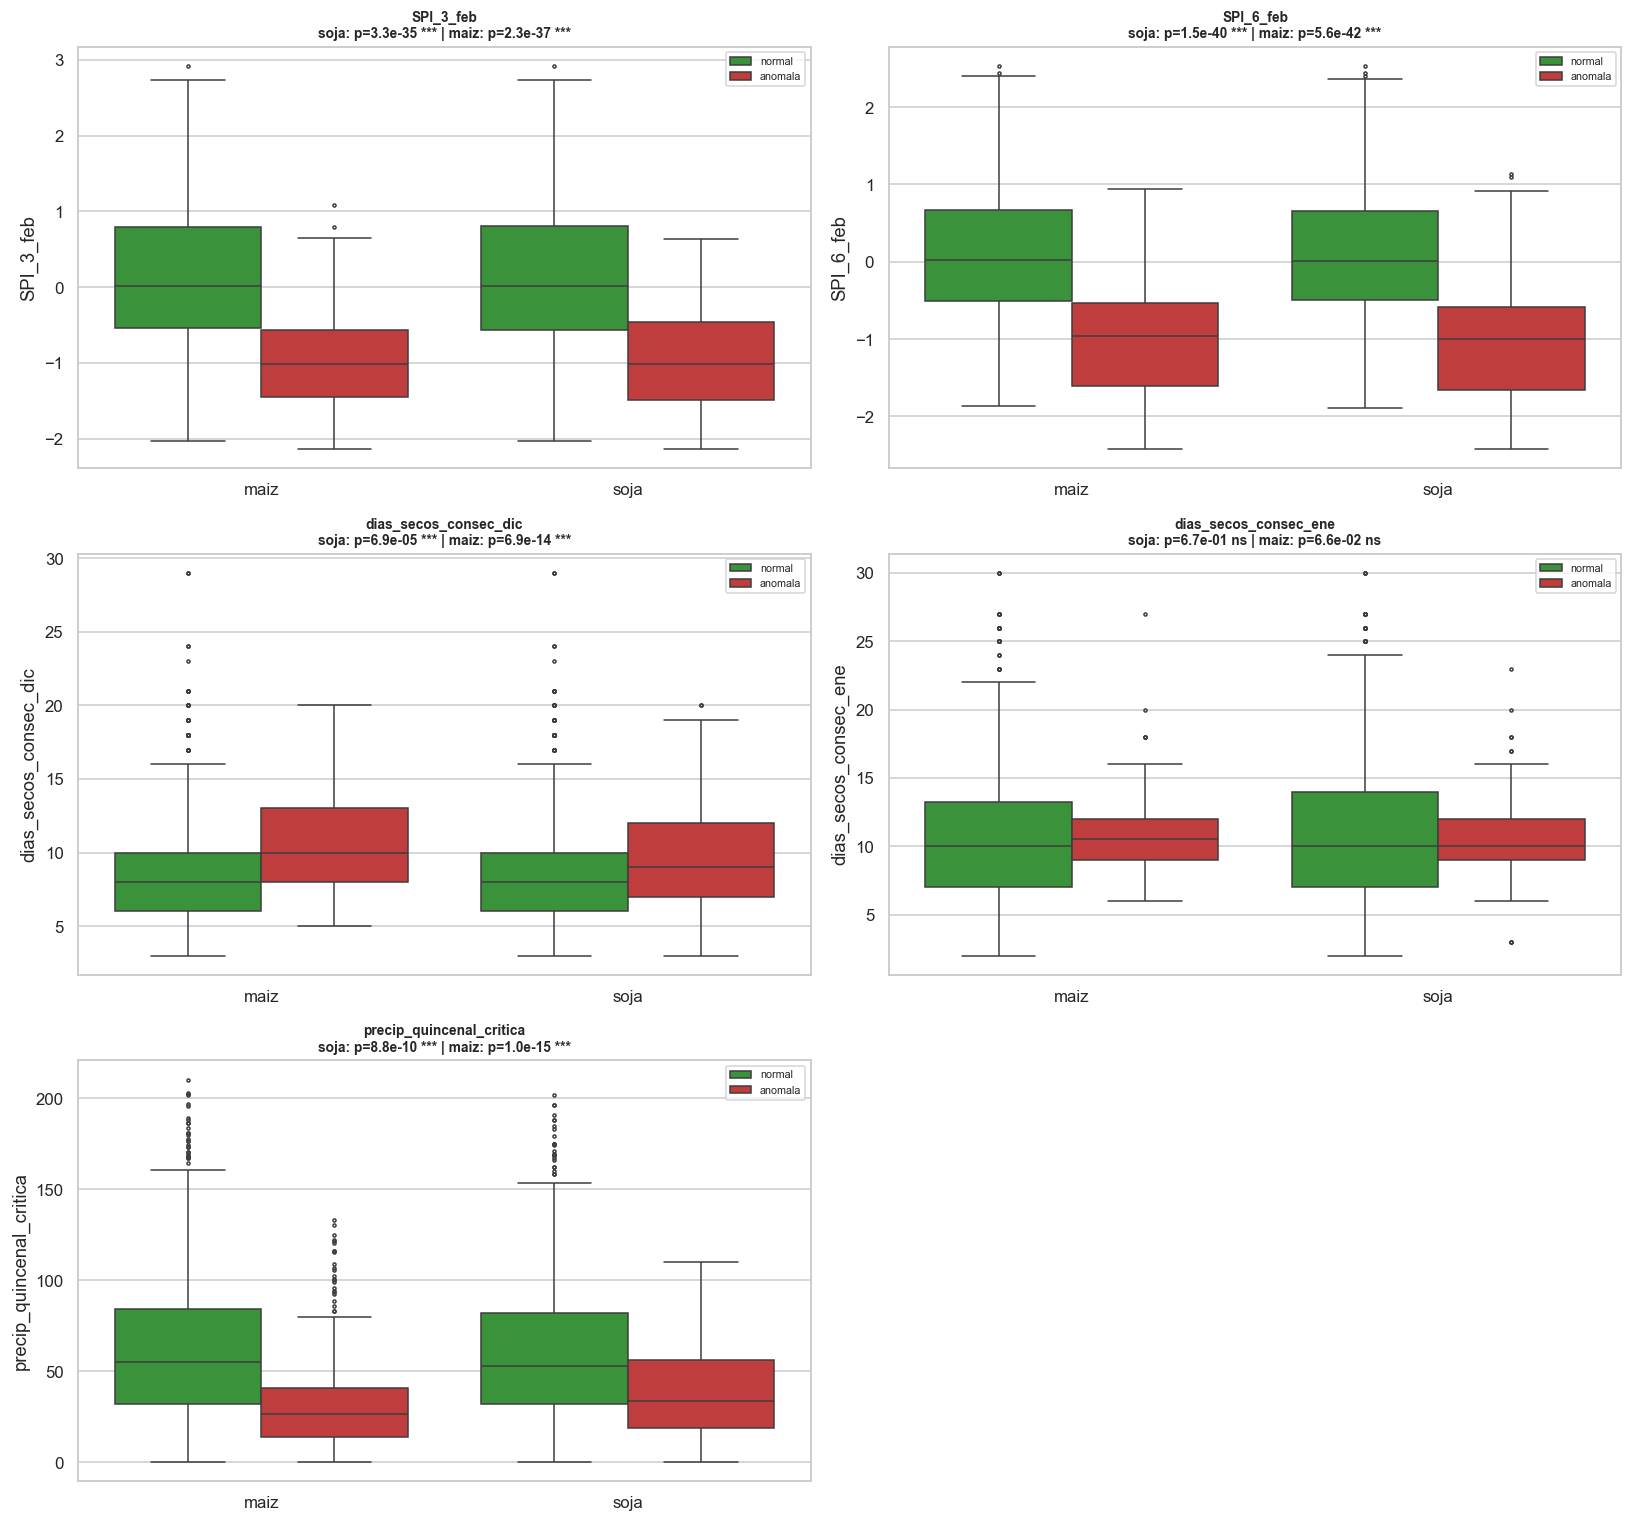

Medias por clase (normal vs anómala), pooled soja+maíz:


label_anomalia,anomala,normal
SPI_3_feb,-0.96,0.12
SPI_6_feb,-1.02,0.12
dias_secos_consec_dic,10.34,8.71
dias_secos_consec_ene,10.68,11.13
precip_quincenal_critica,38.75,61.20


In [30]:
def _estrellas(p):
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "ns"

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
for ax, feat in zip(axes.ravel(), CHIRPS_FEAT_COLS):
    sns.boxplot(data=df, x="cultivo", y=feat, hue="label_anomalia",
                hue_order=["normal", "anomala"], palette=ANOM_COLORS, ax=ax, fliersize=2)
    txt = []
    for cult in ["soja", "maiz"]:
        sub = df[df["cultivo"] == cult]
        a = sub.loc[sub["label_anomalia"] == "normal",  feat].dropna()
        b = sub.loc[sub["label_anomalia"] == "anomala", feat].dropna()
        if len(a) > 5 and len(b) > 5:
            p = mannwhitneyu(a, b).pvalue
            txt.append(f"{cult}: p={p:.1e} {_estrellas(p)}")
    ax.set_title(f"{feat}\n" + " | ".join(txt), fontsize=9)
    ax.set_xlabel(""); ax.legend(fontsize=7, loc="best")
axes.ravel()[-1].axis("off")  # 5 features en grilla 3x2
plt.tight_layout(); plt.show()

print("Medias por clase (normal vs anómala), pooled soja+maíz:")
display(df.groupby("label_anomalia")[CHIRPS_FEAT_COLS].mean().round(2).T)


---
## 7. Redundancia CHIRPS ↔ NASA POWER y set de features definitivo del AE

CHIRPS (satélite calibrado con estaciones) y NASA POWER (reanálisis) aportan **la misma
variable** —precipitación mensual— por dos vías distintas. Antes de definir el input del AE
medimos cuánto se solapan y decidimos con qué fuente quedarnos.


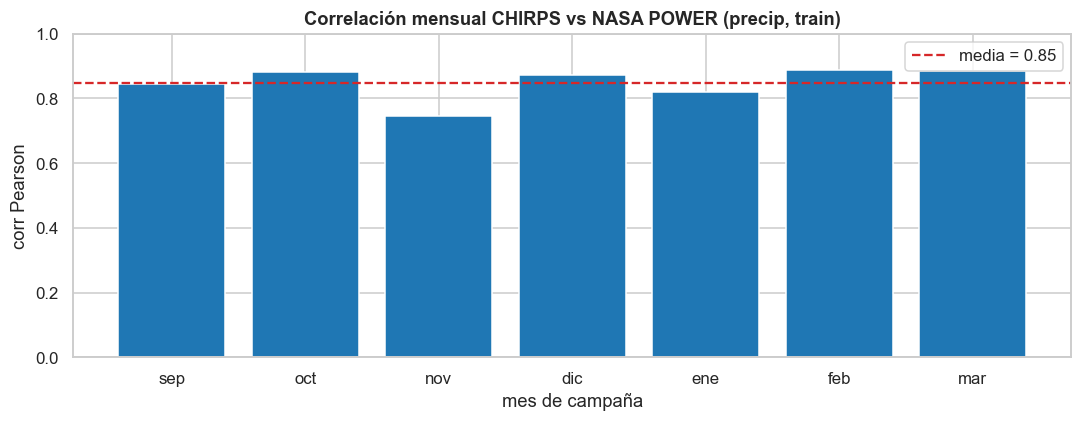

Correlación media CHIRPS↔NASA = 0.85 (rango 0.75 nov – 0.89 feb)
Alta pero NO perfecta → no son redundantes, pero alimentar AMBAS al AE duplicaría la señal de precip en el espacio de entrada.


In [31]:
# Correlación chirps_precip_<mes> vs prectotcorr_<mes> (solo train, rinde válido)
mask_tr = (df["split"] == "train") & df[TARGET].notna()
corr_precip = {}
for m in MESES:
    a, b = f"chirps_precip_{m}", f"prectotcorr_{m}"
    if a in df.columns and b in df.columns:
        corr_precip[m] = df.loc[mask_tr, [a, b]].corr().iloc[0, 1]
corr_precip = pd.Series(corr_precip)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(corr_precip.index, corr_precip.values, color="#1f77b4")
ax.axhline(corr_precip.mean(), color="#d62728", ls="--",
           label=f"media = {corr_precip.mean():.2f}")
ax.set_ylim(0, 1)
ax.set_title("Correlación mensual CHIRPS vs NASA POWER (precip, train)")
ax.set_xlabel("mes de campaña"); ax.set_ylabel("corr Pearson"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Correlación media CHIRPS↔NASA = {corr_precip.mean():.2f} "
      f"(rango {corr_precip.min():.2f} {corr_precip.idxmin()} – "
      f"{corr_precip.max():.2f} {corr_precip.idxmax()})")
print("Alta pero NO perfecta → no son redundantes, pero alimentar AMBAS al AE duplicaría "
      "la señal de precip en el espacio de entrada.")


### 7.1 Decisión: una sola fuente de precipitación mensual

Con correlación media ≈ 0.84, alimentar `chirps_precip_*` **y** `prectotcorr_*` al AE
inflaría artificialmente el peso de la precipitación en el cuello de botella y en el error de
reconstrucción (dos columnas casi colineales por mes). Se elige **CHIRPS** como fuente única
de precip mensual porque está **calibrada con estaciones pluviométricas** (mejor en eventos
extremos, que son justamente los de interés) y tiene mayor resolución espacial (0.05°). Se
**excluye `prectotcorr_*`** del input del AE; NASA POWER sigue aportando temperatura, humedad
y radiación. También se excluye `ws2m_*` por su redundancia intra-bloque extrema (r > 0.96,
sección 3.1).


In [32]:
# ── Set de features DEFINITIVO del AE ────────────────────────────────────────
VARS_DEF = ["t2m", "t2m_max", "t2m_min", "rh2m", "allsky_sfc_sw_dwn"]   # sin ws2m, sin prectotcorr
MENSUALES_DEF = [f"{v}_{m}" for v in VARS_DEF for m in MESES if f"{v}_{m}" in df.columns]
CHIRPS_MENS   = [f"chirps_precip_{m}" for m in MESES if f"chirps_precip_{m}" in df.columns]
CHIRPS_DERIV  = ["SPI_3_feb", "SPI_6_feb", "dias_secos_consec_dic",
                 "dias_secos_consec_ene", "precip_quincenal_critica"]

FEATS_DEF = MENSUALES_DEF + CHIRPS_MENS + ["oni_mean_octfeb"] + CHIRPS_DERIV

print(f"Set definitivo: {len(FEATS_DEF)} features")
print(f"  · NASA mensual (T/HR/rad, sin ws2m ni prectotcorr): {len(MENSUALES_DEF)}")
print(f"  · CHIRPS precip mensual (fuente única):             {len(CHIRPS_MENS)}")
print(f"  · ONI (feature, no criterio):                       1")
print(f"  · CHIRPS derivadas (SPI, rachas, quincena):         {len(CHIRPS_DERIV)}")
print(f"Excluidas vs set previo: ws2m_* (7) + prectotcorr_* (7) = 14 columnas NASA")


Set definitivo: 48 features
  · NASA mensual (T/HR/rad, sin ws2m ni prectotcorr): 35
  · CHIRPS precip mensual (fuente única):             7
  · ONI (feature, no criterio):                       1
  · CHIRPS derivadas (SPI, rachas, quincena):         5
Excluidas vs set previo: ws2m_* (7) + prectotcorr_* (7) = 14 columnas NASA


### 7.2 PCA con el set definitivo — ¿cambia el cuello de botella?

Re-corremos la varianza explicada acumulada sobre `FEATS_DEF` (solo train) y la comparamos
con el rango k = 8..14 que sugería el set previo (49 features NASA + ONI).


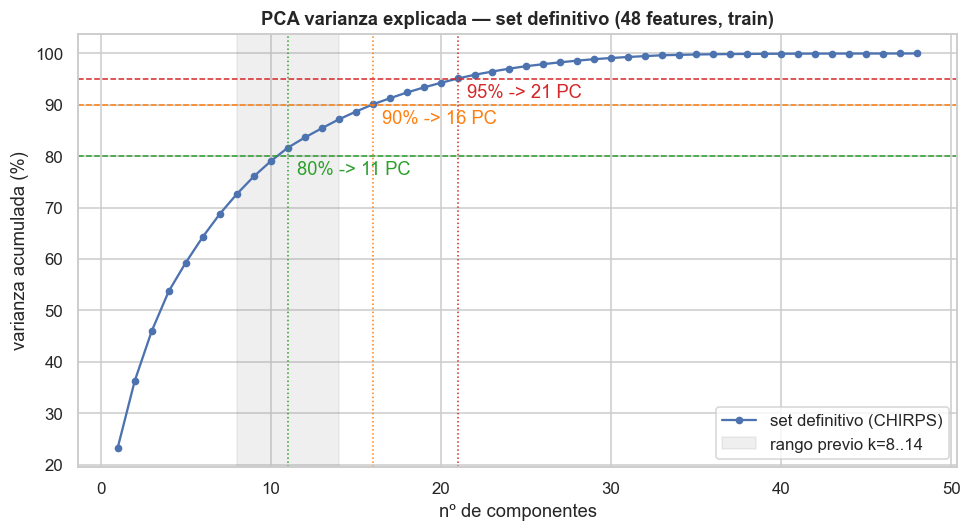

Componentes para 80/90/95% de varianza (set definitivo): 11 / 16 / 21
Cuello de botella sugerido: entre 8 y 16 neuronas.
Comparación con el set previo (49 NASA+ONI -> ~14 PC al 90%): sin cambio relevante respecto del rango k=8..14.


In [33]:
X_def, _, _ = escalar_con_train(FEATS_DEF)
X_def_train = X_def[df["split"] == "train"].values

pca_def  = PCA(random_state=RANDOM_STATE).fit(X_def_train)
var_acum = np.cumsum(pca_def.explained_variance_ratio_) * 100
d80, d90, d95 = [int(np.argmax(var_acum >= t) + 1) for t in (80, 90, 95)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(var_acum) + 1), var_acum, marker="o", ms=4, label="set definitivo (CHIRPS)")
for t, n, c in [(80, d80, "#2ca02c"), (90, d90, "#ff7f0e"), (95, d95, "#d62728")]:
    ax.axhline(t, color=c, ls="--", lw=1); ax.axvline(n, color=c, ls=":", lw=1)
    ax.annotate(f"{t}% -> {n} PC", (n, t), textcoords="offset points", xytext=(6, -12), color=c)
ax.axvspan(8, 14, color="grey", alpha=.12, label="rango previo k=8..14")
ax.set_title(f"PCA varianza explicada — set definitivo ({len(FEATS_DEF)} features, train)")
ax.set_xlabel("nº de componentes"); ax.set_ylabel("varianza acumulada (%)"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Componentes para 80/90/95% de varianza (set definitivo): {d80} / {d90} / {d95}")
print(f"Cuello de botella sugerido: entre {d90//2} y {d90} neuronas.")
print(f"Comparación con el set previo (49 NASA+ONI -> ~14 PC al 90%): "
      f"{'sin cambio relevante' if 8 <= d90 <= 16 else 'CAMBIA'} respecto del rango k=8..14.")


---
## 8. Columna de confianza (diagnóstico post-hoc — NO entra a ningún modelo)

`confianza_anomalia = es_anomala & (SPI_3_feb < −1.0)`: marca las anomalías de rinde que
**además** coinciden con un déficit hídrico estacional fuerte. **No modifica la etiqueta ni se
alimenta al AE.** Es una herramienta para interpretar los falsos positivos del detector: una
anomalía SIN SPI adverso sugiere una causa no-hídrica (granizo, plaga, o el **efecto napa**
amortiguando una seca), mientras que una caída CON SPI adverso es una anomalía de sequía
"de manual".


In [34]:
df["spi_adverso"]        = df["SPI_3_feb"] < -1.0
df["confianza_anomalia"] = df["es_anomala"] & df["spi_adverso"]

print("Tabla de 4 cuadrantes (es_anomala × spi_adverso), por cultivo:\n")
for cult in ["soja", "maiz"]:
    sub = df[df["cultivo"] == cult]
    tab = pd.crosstab(sub["es_anomala"], sub["spi_adverso"],
                      rownames=["es_anomala"], colnames=["SPI_3_feb < -1.0"])
    print(f"── {cult} ──")
    display(tab)
    n_conf = int((sub["confianza_anomalia"]).sum())
    n_anom = int(sub["es_anomala"].sum())
    fp_pot = int((sub["es_anomala"] & ~sub["spi_adverso"]).sum())
    resil  = int((~sub["es_anomala"] & sub["spi_adverso"]).sum())
    print(f"  Anomalías totales: {n_anom} | confirmadas por SPI (alta confianza): {n_conf} "
          f"({100*n_conf/max(n_anom,1):.0f}%)")
    print(f"  Anómala SIN SPI adverso (posible FP / causa no-hídrica): {fp_pot}")
    print(f"  Normal CON SPI adverso (posible resiliencia / efecto napa): {resil}\n")

print("Recordatorio: 'confianza_anomalia' es diagnóstico post-hoc, no un clasificador ni "
      "input del AE; no modifica 'es_anomala'.")


Tabla de 4 cuadrantes (es_anomala × spi_adverso), por cultivo:

── soja ──


SPI_3_feb < -1.0,False,True
es_anomala,,
False,895,102
True,73,73


  Anomalías totales: 146 | confirmadas por SPI (alta confianza): 73 (50%)
  Anómala SIN SPI adverso (posible FP / causa no-hídrica): 73
  Normal CON SPI adverso (posible resiliencia / efecto napa): 102

── maiz ──


SPI_3_feb < -1.0,False,True
es_anomala,,
False,897,103
True,72,72


  Anomalías totales: 144 | confirmadas por SPI (alta confianza): 72 (50%)
  Anómala SIN SPI adverso (posible FP / causa no-hídrica): 72
  Normal CON SPI adverso (posible resiliencia / efecto napa): 103

Recordatorio: 'confianza_anomalia' es diagnóstico post-hoc, no un clasificador ni input del AE; no modifica 'es_anomala'.


---
## 9. Exportación de artefactos para el autoencoder — por cultivo

Por cada cultivo (`_soja` / `_maiz`):

| Archivo | Contenido |
|---|---|
| `labels_anomalia_{cultivo}.csv` | `departamento, campania_inicio, z_rinde, es_anomala, confianza_anomalia` |
| `train_normal_idx_{cultivo}.csv` | claves `(departamento, campania_inicio)` de train ∩ normal (≤ 2017, z_rinde ≥ −1.5) |
| `scaler_params_{cultivo}.csv` | media y desvío **por depto × feature** del set definitivo, calculados **solo sobre train-normal** |


In [36]:
PROC = ROOT / "data" / "processed"

for cult in ["soja", "maiz"]:
    sub = df[df["cultivo"] == cult].copy()

    # 1) labels
    labels = sub[["departamento", "campania_inicio", "z_rinde",
                  "es_anomala", "confianza_anomalia"]].sort_values(
                      ["departamento", "campania_inicio"])
    labels.to_csv(ROOT / "data" / "csv" / f"labels_anomalia_{cult}.csv", index=False)

    # 2) train ∩ normal (campania <= 2017 y NO anómala -> z_rinde >= -1.5 o sin base)
    tn_mask = (sub["split"] == "train") & (~sub["es_anomala"])
    train_normal = (sub.loc[tn_mask, ["departamento", "campania_inicio"]]
                    .drop_duplicates().sort_values(["departamento", "campania_inicio"]))
    train_normal.to_csv(ROOT / "data" / "csv" / f"train_normal_idx_{cult}.csv", index=False)

    # 3) scaler: media/desvío por depto × feature, SOLO sobre train-normal
    tn = sub.loc[tn_mask]
    filas = []
    for feat in FEATS_DEF:
        g = tn.groupby("departamento")[feat]
        filas.append(pd.DataFrame({"feature": feat, "departamento": g.mean().index,
                                    "mean": g.mean().values, "std": g.std().values}))
    scaler = pd.concat(filas, ignore_index=True)
    scaler.to_csv(ROOT / "data" / "csv" / f"scaler_params_{cult}.csv", index=False)

    print(f"[{cult}] labels={labels.shape} | train_normal={train_normal.shape[0]} claves "
          f"| scaler={scaler.shape} ({len(FEATS_DEF)} feats × {tn['departamento'].nunique()} deptos)")

print("\nArtefactos exportados en:", ROOT / "data" / "csv")
print("  labels_anomalia_{soja,maiz}.csv · train_normal_idx_{soja,maiz}.csv · scaler_params_{soja,maiz}.csv")


[soja] labels=(1143, 5) | train_normal=855 claves | scaler=(1248, 4) (48 feats × 26 deptos)
[maiz] labels=(1144, 5) | train_normal=864 claves | scaler=(1248, 4) (48 feats × 26 deptos)

Artefactos exportados en: c:\Users\balta\Documents\ML\Trabajo_final_ML\data\csv
  labels_anomalia_{soja,maiz}.csv · train_normal_idx_{soja,maiz}.csv · scaler_params_{soja,maiz}.csv
